<a href="https://colab.research.google.com/github/cindyrenxy/ac209b-project/blob/emilyc/cs1090b_ms4_main_group77.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Milestone 4 Main Notebook — MiDaS Final Modeling Pipeline

**Canvas Project Number:** #77  
**Group Members:** Emily Chen, Cindy Ren, Alice Wang  
**Course / Milestone:** CS1090B — Milestone 4 / Final Modeling  

This notebook is designed as the designated **main pipeline notebook** for the final milestone. It demonstrates the project end-to-end: data loading, data quality checks, preprocessing, baseline CNN modeling, final model sections, interpretability sections, and final result reporting.

At this stage, the completed Milestone 3 components are copied forward and cleaned into an MS4-ready format. New final-modeling sections for **ViT-B/16**, **Grad-CAM**, and **attention rollout** are intentionally formatted as placeholders to fill in later.


## Table of Contents

0. Milestone 4 scope and notebook status
1. Environment setup and dependencies
2. Data description and loading
3. Data quality checks and EDA recap
   - 3A. Per-class image grids
   - 3B. Per-class pixel statistics
   - 3C. Similarity and train-test leakage analysis
4. Feature engineering and preprocessing
   - 4A. Load preprocessed cache
   - 4B. Transform definitions and augmentation examples
   - 4C. Dataset splits and DataLoaders
5. Baseline model: ResNet-18
6. Baseline evaluation and error analysis
7. Final model: ViT-B/16 **[to fill in]**
8. Interpretability analysis **[to fill in]**
   - 8A. Grad-CAM for ResNet-18
   - 8B. Attention rollout for ViT-B/16
9. Final model comparison and reported results **[to fill in]**
10. Discussion, limitations, and reproducibility checklist **[to fill in]**


## 0. Milestone 4 scope and notebook status

### What is already implemented from Milestone 3
- Data path setup for Colab and local execution
- MiDaS-60 data loading using `torchvision.datasets.ImageFolder`
- Class count checks and EDA visualizations
- Pixel-level brightness / contrast analysis
- ResNet-18 feature-based similarity scan for near-duplicates and possible train-test leakage
- Cleaned 224×224 image cache construction
- Training / validation split and DataLoaders
- ResNet-18 baseline fine-tuning
- Baseline test-set evaluation, confusion matrix, per-class F1, and hard-class analysis

### What still needs to be added for the final milestone
- ViT-B/16 training and evaluation using the same data split and metrics
- Grad-CAM for the ResNet-18 baseline
- Attention rollout for the ViT-B/16 model
- Final side-by-side result table and written interpretation
- Final reproducibility notes and submission checklist


## 1. Environment setup and dependencies

Run all cells in this section first. The code detects whether the notebook is running on Google Colab or a local machine, configures data/checkpoint paths, imports dependencies, sets random seeds, selects the compute device, and extracts the dataset if needed.

For reproducibility, the companion file `requirements_ms4.txt` records the core Python libraries used by this notebook. In Colab, the common packages are usually preinstalled; the pip cell below is optional and intentionally commented out to avoid unnecessary reinstalling.


In [ ]:
# Optional dependency installation for a fresh environment.
# Uncomment if needed.
# %pip install --quiet -r requirements_ms4.txt


In [1]:
# ==== 1A. Environment detection ====
import sys, os

ON_COLAB = 'google.colab' in sys.modules or 'COLAB_GPU' in os.environ
print('Running on:', 'Google Colab' if ON_COLAB else 'Local machine')

Running on: Google Colab


In [2]:
# ==== 1B. Mount Google Drive (Colab only) ====
if ON_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted.')
else:
    print('Skipped — not on Colab.')

Mounted at /content/drive
Drive mounted.


In [3]:
# ==== 1C. Path configuration ====

if ON_COLAB:
    DRIVE_ROOT       = '/content/drive/MyDrive/APcomp209/MiDaS'
    DRIVE_CACHE_ROOT = DRIVE_ROOT
    LOCAL_WORK_ROOT  = '/content'
    CHECKPOINT_DIR   = os.path.join(DRIVE_ROOT, 'ms4_checkpoints')
else:
    LOCAL_WORK_ROOT  = 'data'
    DRIVE_CACHE_ROOT = LOCAL_WORK_ROOT
    CHECKPOINT_DIR   = os.path.join(LOCAL_WORK_ROOT, 'ms4_checkpoints')

# ── Dataset variant ──────────────────────────────────────────────────────────
DATASET_NAME = 'MiDaS-60_small'

# ── Tar file config (Colab: tar lives on Drive, is copied & extracted each session) ─
TAR_NAME   = f'{DATASET_NAME}.tar'                         # filename on Drive
DRIVE_TAR  = os.path.join(DRIVE_ROOT if ON_COLAB else LOCAL_WORK_ROOT, TAR_NAME)
LOCAL_TAR  = os.path.join(LOCAL_WORK_ROOT, TAR_NAME)      # /content/ scratch copy
EXTRACT_TO = LOCAL_WORK_ROOT   # extract directly into /content/

# RAW_TRAIN_DIR / RAW_TEST_DIR are set in §2F after extraction (Colab)
# or resolved directly from LOCAL_WORK_ROOT (local machine).

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Results directory — EDA figures are saved here instead of displayed inline
RESULTS_EDA_DIR = os.path.join(
    DRIVE_ROOT if ON_COLAB else '.', 'results', 'eda'
)
os.makedirs(RESULTS_EDA_DIR, exist_ok=True)

print(f'ON_COLAB        : {ON_COLAB}')
print(f'TAR_NAME        : {TAR_NAME}')
print(f'DRIVE_TAR       : {DRIVE_TAR}')
print(f'LOCAL_TAR       : {LOCAL_TAR}')
print(f'EXTRACT_TO      : {EXTRACT_TO}')
print(f'CHECKPOINT_DIR  : {CHECKPOINT_DIR}')
print(f'RESULTS_EDA_DIR : {RESULTS_EDA_DIR}')

ON_COLAB        : True
TAR_NAME        : MiDaS-60_small.tar
DRIVE_TAR       : /content/drive/MyDrive/APcomp209/MiDaS/MiDaS-60_small.tar
LOCAL_TAR       : /content/MiDaS-60_small.tar
EXTRACT_TO      : /content
CHECKPOINT_DIR  : /content/drive/MyDrive/APcomp209/MiDaS/ms4_checkpoints
RESULTS_EDA_DIR : /content/drive/MyDrive/APcomp209/MiDaS/results/eda


In [4]:
# ==== 1D. Imports ====
import random, time, copy, subprocess, shutil, tarfile
from pathlib import Path
from collections import Counter
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from skimage.metrics import structural_similarity as ssim_fn

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [5]:
# ==== 1E. Seeds & device ====
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [6]:
# ==== 1F. Copy & extract dataset tar, set raw data paths ====
# Colab: /content is wiped each session — copy tar from Drive and extract.
# Local: data is assumed to already be present; copy/extract is skipped.

if ON_COLAB:
    # ── Step 1: copy tar to /content local scratch ───────────────────────────
    if not os.path.exists(LOCAL_TAR):
        print(f'Copying {TAR_NAME} from Drive → /content ...')
        shutil.copy2(DRIVE_TAR, LOCAL_TAR)
        size_mb = os.path.getsize(LOCAL_TAR) / 1e6
        print(f'  Done ({size_mb:.0f} MB)')
    else:
        print(f'Tar already in /content — skipping copy.')

    # ── Step 2: extract tar into EXTRACT_TO ──────────────────────────────────
    os.makedirs(EXTRACT_TO, exist_ok=True)
    RAW_DATASET_DIR = os.path.join(EXTRACT_TO, DATASET_NAME)

    if not os.path.exists(RAW_DATASET_DIR):
        print(f'Extracting {TAR_NAME} → {EXTRACT_TO} ...')
        with tarfile.open(LOCAL_TAR) as tar:
            tar.extractall(EXTRACT_TO)
        print('  Extraction complete.')
        if not os.path.exists(RAW_DATASET_DIR):
            raise FileNotFoundError(
                f'Expected {RAW_DATASET_DIR} after extraction — '
                f'found: {[d for d in os.listdir(EXTRACT_TO) if os.path.isdir(os.path.join(EXTRACT_TO, d))]}'
            )
    else:
        print(f'Already extracted — skipping.')

else:
    RAW_DATASET_DIR = os.path.join(LOCAL_WORK_ROOT, DATASET_NAME)

RAW_TRAIN_DIR = os.path.join(RAW_DATASET_DIR, 'train')
RAW_TEST_DIR  = os.path.join(RAW_DATASET_DIR, 'test')

print(f'RAW_DATASET_DIR : {RAW_DATASET_DIR}')
print(f'RAW_TRAIN_DIR   : {RAW_TRAIN_DIR}  (exists: {os.path.exists(RAW_TRAIN_DIR)})')
print(f'RAW_TEST_DIR    : {RAW_TEST_DIR}   (exists: {os.path.exists(RAW_TEST_DIR)})')


Copying MiDaS-60_small.tar from Drive → /content ...
  Done (2251 MB)
Extracting MiDaS-60_small.tar → /content ...


/tmp/ipykernel_4059/763104844.py:22: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(EXTRACT_TO)


  Extraction complete.
RAW_DATASET_DIR : /content/MiDaS-60_small
RAW_TRAIN_DIR   : /content/MiDaS-60_small/train  (exists: True)
RAW_TEST_DIR    : /content/MiDaS-60_small/test   (exists: True)


## 2. Data description and loading

**Dataset:** MiDaS-60  
**Source:** `https://github.com/MinecraftDataset/MiDaS/tree/main.`

### Summary
- The dataset contains labeled images organized into training and test folders.
- Each class corresponds to a visual category in the environment.
- Our current framing emphasizes **block classification**.
- The images appear to vary in texture, color, viewpoint, and scene complexity.

### Why this dataset is useful
This dataset allows us to test whether image features are sufficient for distinguishing meaningful environmental categories and whether label granularity affects modeling success.

### Notes / caveats
- Some classes may be visually similar.
- Class imbalance may affect training and evaluation.
- A biome-level formulation may introduce label noise if multiple visually distinct blocks are merged together.

In [13]:
# ==== 2A. Load raw dataset (EDA / inspection — no augmentation) ====
eda_transform = transforms.ToTensor()

eda_train_ds = datasets.ImageFolder(RAW_TRAIN_DIR, transform=eda_transform)
eda_test_ds  = datasets.ImageFolder(RAW_TEST_DIR,  transform=eda_transform)

class_names = eda_train_ds.classes
num_classes  = len(class_names)

print(f'Train images : {len(eda_train_ds)}')
print(f'Test images  : {len(eda_test_ds)}')
print(f'Classes      : {num_classes}')

Train images : 32400
Test images  : 3600
Classes      : 60


In [14]:
# ==== 2B. Per-class image count table ====
train_counts = Counter([lbl for _, lbl in eda_train_ds.samples])
test_counts  = Counter([lbl for _, lbl in eda_test_ds.samples])

class_df = pd.DataFrame({
    'class_name':  class_names,
    'train_count': [train_counts.get(i, 0) for i in range(num_classes)],
    'test_count':  [test_counts.get(i,  0) for i in range(num_classes)],
})
class_df['total'] = class_df['train_count'] + class_df['test_count']
class_df = class_df.sort_values('total', ascending=False).reset_index(drop=True)

display(class_df)
print('Total images:', class_df['total'].sum())

,class_name,train_count,test_count,total
0,acacia_log,540,60,600
1,acacia_planks,540,60,600
2,bed,540,60,600
3,birch_log,540,60,600
4,birch_planks,540,60,600
5,bookshelf,540,60,600
6,bricks,540,60,600
7,chest,540,60,600
8,clay,540,60,600
9,coal_ore,540,60,600


Total images: 36000


## 3. Data quality checks and EDA recap

### Key questions
- Are classes balanced across train and test?
- What do images in each class actually look like? Are any visually ambiguous?
- Are there near-duplicate images within a split or across train/test (leakage)?
- Do per-class brightness / contrast statistics reveal spurious cues?

### Per-class image grids

Each grid shows an image in one class, laid out as 10 columns × 6 rows = 60 thumbnails for both the training and test splits. All grids were also manually reviewed to ensure data quality (inspection code not included).

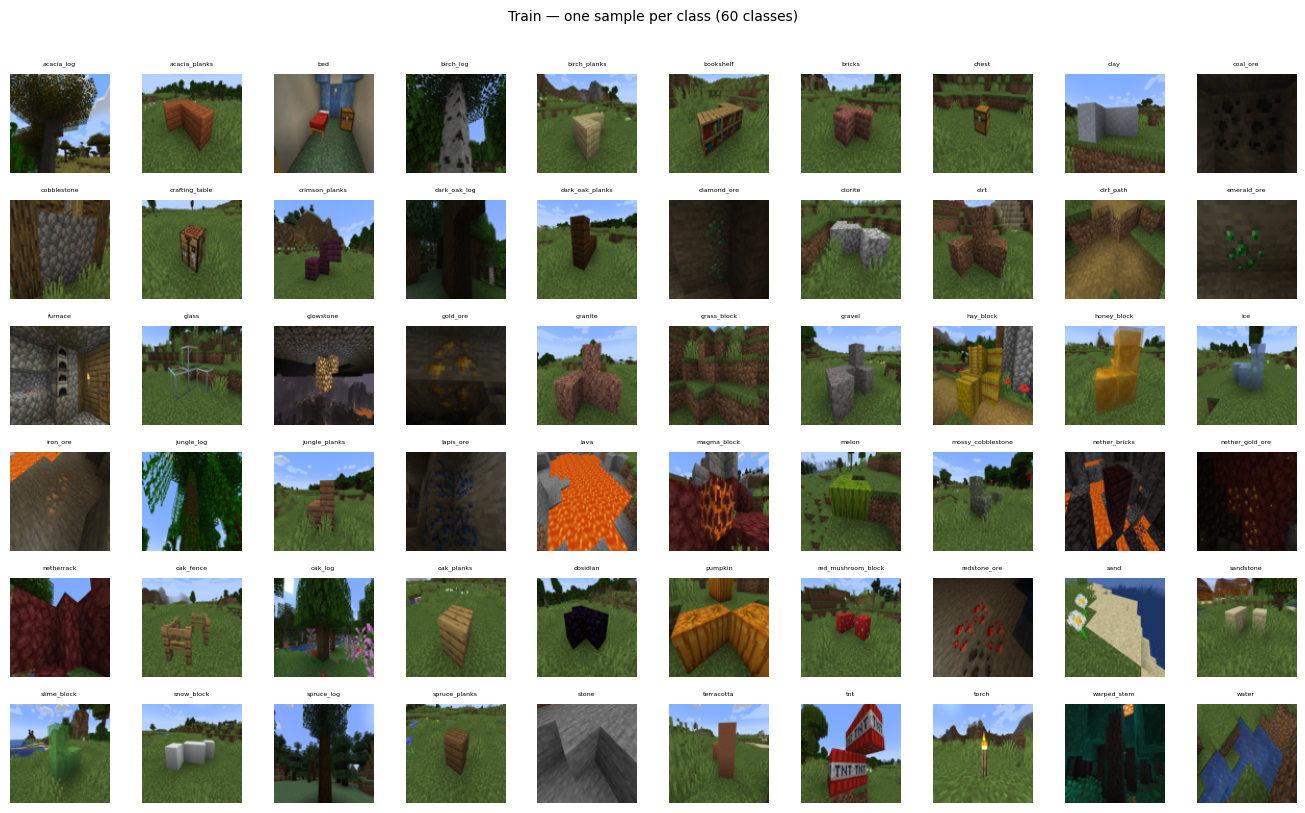

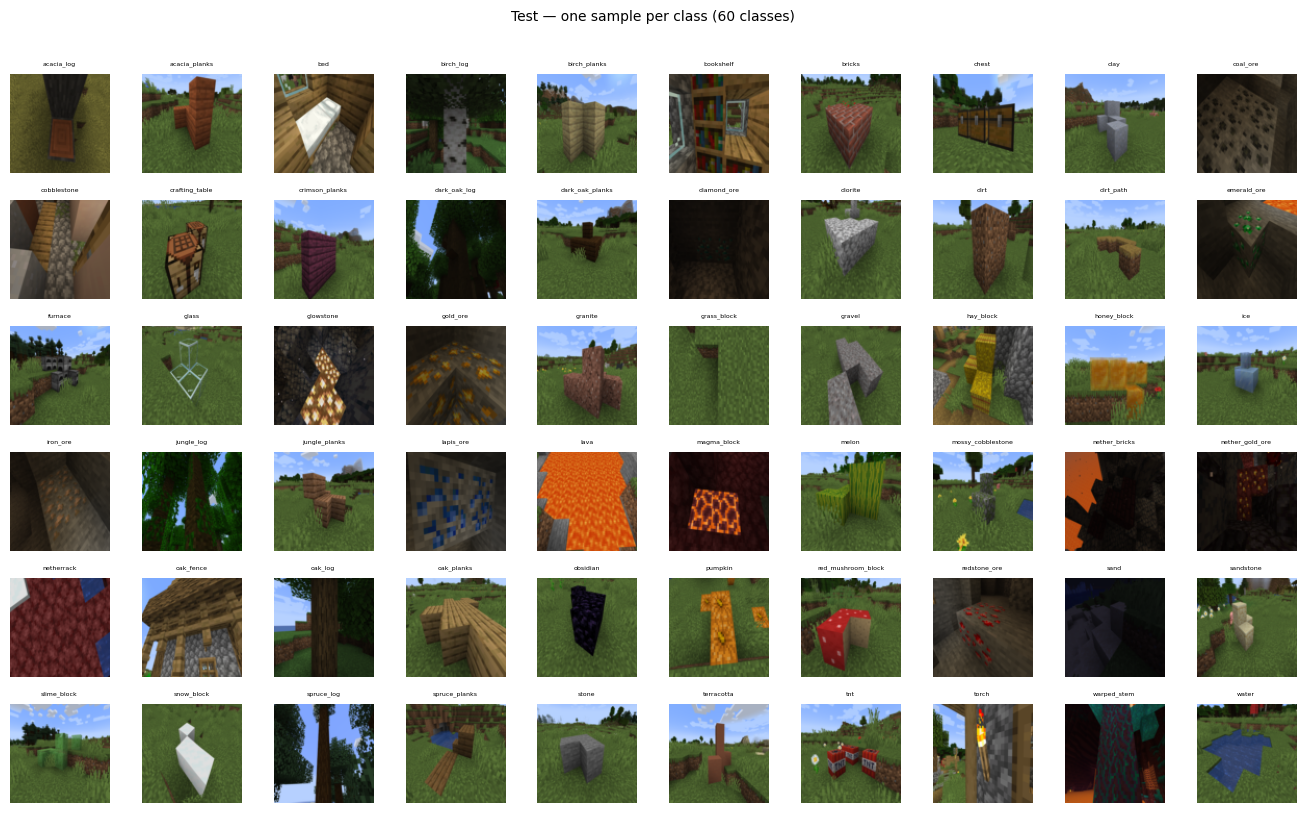

In [15]:
# ==== 3A. Per-class image grids ====
# Displays one 10×6 grid for train and one for test.
# Each cell shows one sample image from that class.

THUMB_OV = (96, 96)
COLS, ROWS = 10, 6   # 10 cols × 6 rows = 60 classes

def show_sample_grid(split_dir, split_name, class_names, thumb=THUMB_OV):
    """One thumbnail per class, arranged in a 10×6 grid."""
    cols, rows = 10, 6
    fig, axes = plt.subplots(rows, cols, figsize=(cols * thumb[0] / 72,
                                                   rows * thumb[1] / 72))
    axes_flat = axes.flatten()

    for ax, cls_name in zip(axes_flat, class_names):
        cls_path  = os.path.join(split_dir, cls_name)
        img_files = sorted(
            f for f in os.listdir(cls_path)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        )
        with Image.open(os.path.join(cls_path, img_files[0])) as img:
            ax.imshow(img.convert('RGB').resize(thumb, Image.BILINEAR))
        ax.axis('off')
        ax.set_title(cls_name, fontsize=4.5)

    for ax in axes_flat[len(class_names):]:
        ax.axis('off')

    fig.suptitle(f'{split_name} — one sample per class (60 classes)',
                 fontsize=10, y=1.01)
    plt.tight_layout()
    plt.show()

show_sample_grid(RAW_TRAIN_DIR, 'Train', class_names)
show_sample_grid(RAW_TEST_DIR,  'Test',  class_names)

### Per-class pixel statistics

Mean brightness and pixel standard deviation per class reveal lighting or
contrast biases that could act as spurious classification cues.

Classes:   0%|          | 0/60 [00:00<?, ?it/s]

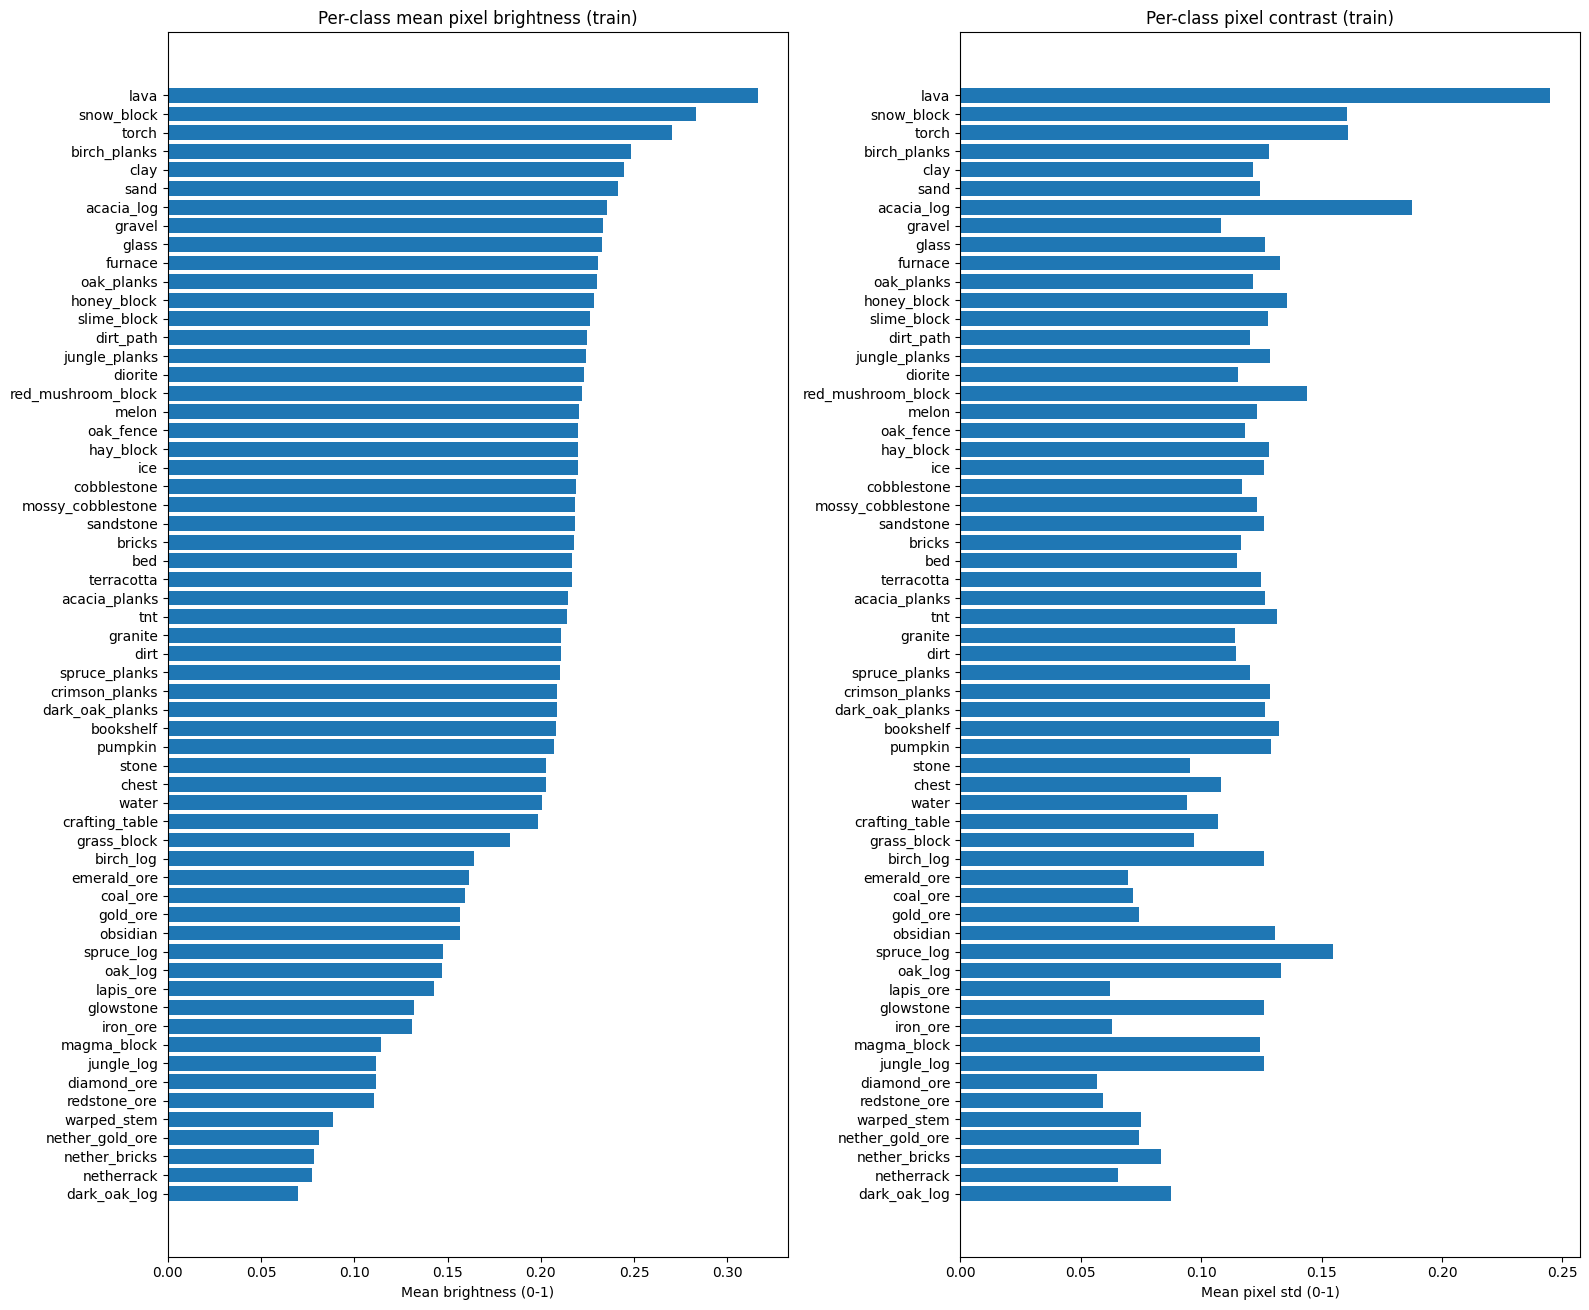

In [16]:
# ==== 3B. Per-class mean brightness & contrast ====
stats = []
for cls_name in tqdm(class_names, desc='Classes'):
    cls_path = os.path.join(RAW_TRAIN_DIR, cls_name)
    means, stds = [], []
    for fname in os.listdir(cls_path):
        if not fname.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue
        with Image.open(os.path.join(cls_path, fname)) as img:
            arr = np.array(img.convert('RGB'), dtype=np.float32) / 255.0
            means.append(arr.mean())
            stds.append(arr.std())
    stats.append({'class': cls_name,
                  'mean_brightness': np.mean(means),
                  'mean_std': np.mean(stds)})

stats_df = pd.DataFrame(stats).sort_values('mean_brightness')

fig, axes = plt.subplots(1, 2, figsize=(16, max(5, num_classes * 0.22)))
axes[0].barh(stats_df['class'], stats_df['mean_brightness'])
axes[0].set_xlabel('Mean brightness (0-1)')
axes[0].set_title('Per-class mean pixel brightness (train)')
axes[1].barh(stats_df['class'], stats_df['mean_std'])
axes[1].set_xlabel('Mean pixel std (0-1)')
axes[1].set_title('Per-class pixel contrast (train)')
plt.tight_layout()
plt.show()

### Similarity & data-leakage analysis
To detect redundant samples and potential train–test leakage, we used cosine similarity on deep feature embeddings (e.g., ResNet-18 pooled features) with a threshold of 0.98 to flag highly similar image pairs.

We evaluated similarity in two settings: (1) intra-split, to identify near-duplicates within the training or test sets, and (2) cross-split, to detect images appearing in both training and test sets (leakage risk). Flagged training images were removed to reduce redundancy and avoid leakage, while the test set was left unchanged to preserve evaluation consistency.

In total, 36 training images were removed (31 intra-train duplicates across 11 classes, and 5 cross-split overlaps across 4 classes). No duplicates were found within the test set. The training set size changed from 32,400 → 32,364, while the test set remained at 3,600.

Of note, we initially planned to incorporate SSIM and histogram correlation as complementary metrics, but did not include them due to computational constraints.

In [17]:
# ==== 3C-0. Shared helpers for similarity computation ====

_feat_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
_feat_model.fc = nn.Identity()
_feat_model.eval()
_feat_model = _feat_model.to(device)

_feat_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def extract_features(paths, batch_size=64):
    """Batched GPU feature extraction; returns CPU tensor (N, 512)."""
    tensors = []
    for p in paths:
        with Image.open(p) as img:
            tensors.append(_feat_transform(img.convert('RGB')))
    all_feats = []
    with torch.no_grad():
        for i in range(0, len(tensors), batch_size):
            batch = torch.stack(tensors[i:i + batch_size]).to(device)
            all_feats.append(_feat_model(batch).cpu())
    return torch.cat(all_feats)

def cosine_sim_matrix(feats_a, feats_b=None):
    """
    Returns cosine similarity matrix.
    If feats_b is None, computes self-similarity (intra).
    Both inputs are CPU tensors; computation is done on GPU if available.
    """
    a = nn.functional.normalize(feats_a, dim=1).to(device)
    b = nn.functional.normalize(feats_b if feats_b is not None else feats_a, dim=1).to(device)
    return (a @ b.T).cpu().numpy()

FEAT_T     = 0.98   # cosine similarity threshold — flag as near-duplicate
TOP_K_SHOW = 3      # pairs to visualise per class

print(f'Helpers ready. Feature model on: {next(_feat_model.parameters()).device}')

Helpers ready. Feature model on: cuda:0


Intra-split [train]:   0%|          | 0/60 [00:00<?, ?it/s]

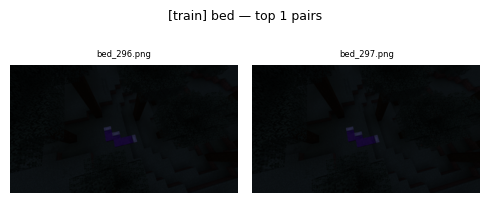

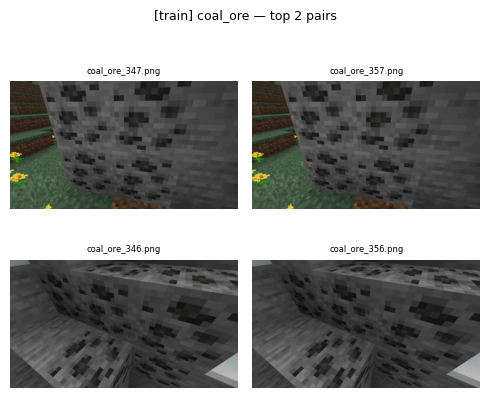

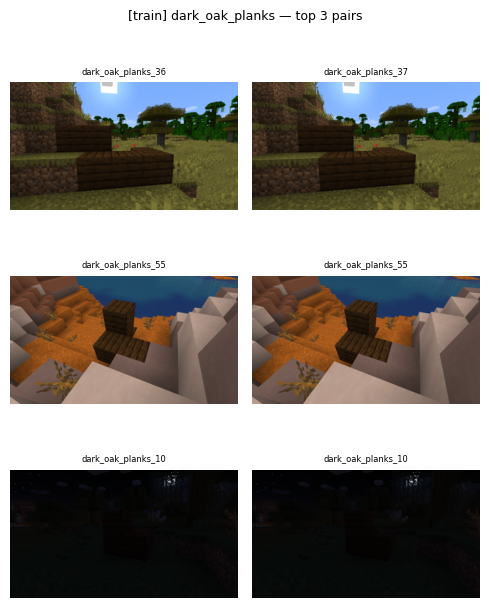

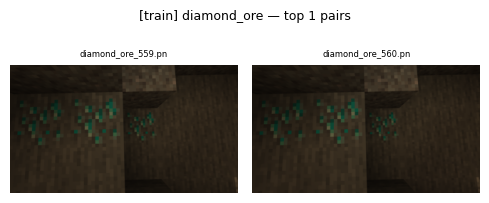

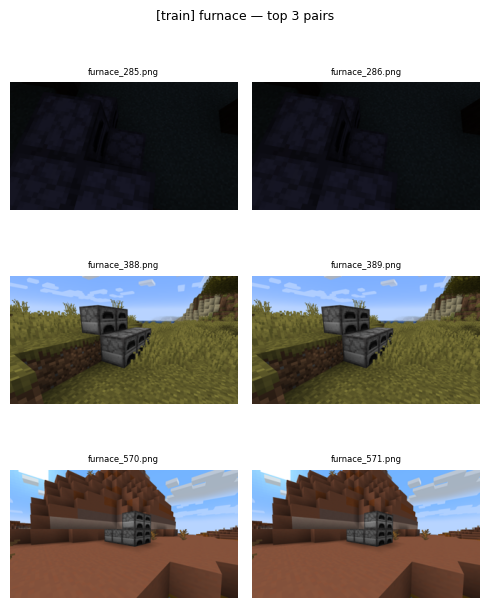

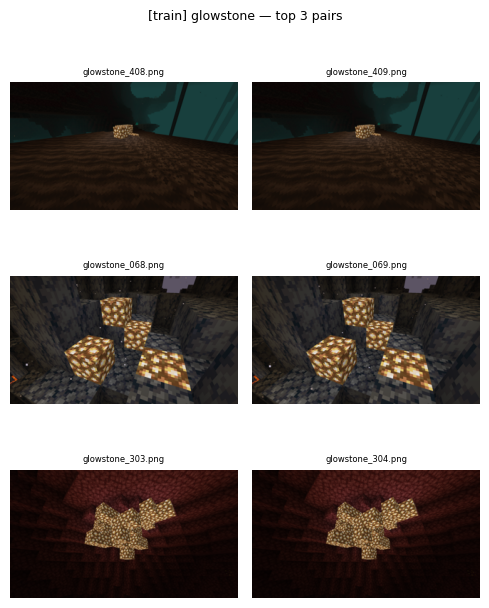

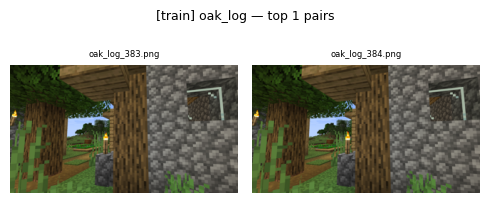

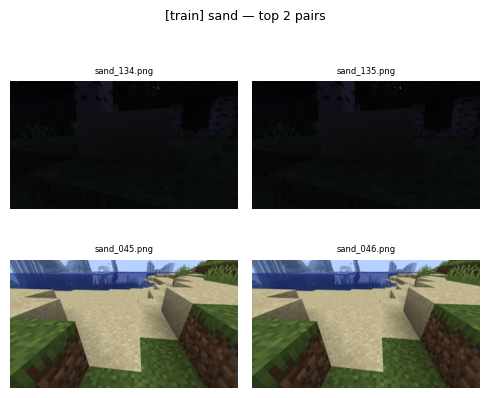

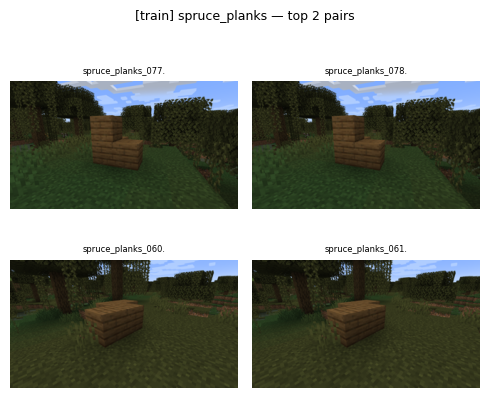

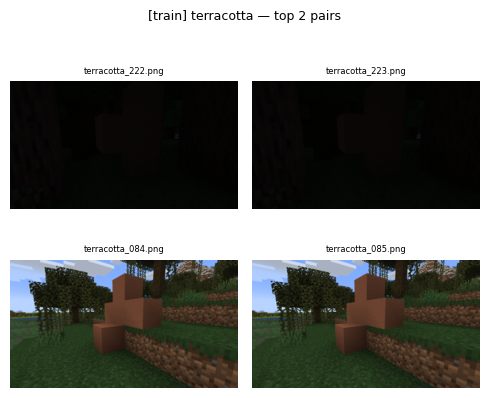

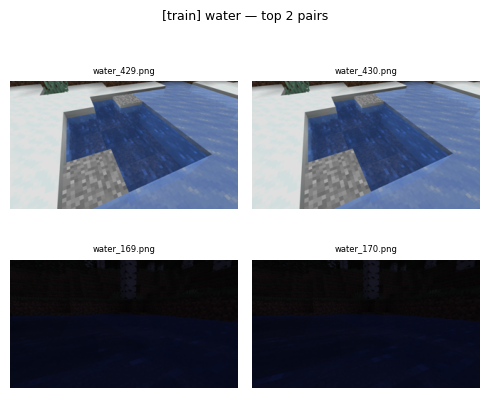

31 intra-train pair(s) flagged (cos >= 0.98)


In [18]:
# ==== 3C-1a. Intra-split near-duplicate scan [train] ====

FEAT_T     = 0.98
TOP_K_SHOW = 3

intra_flagged_train = []   # (class, img_A, img_B, cos_score)

for cls_name in tqdm(class_names, desc='Intra-split [train]'):
    cls_path  = os.path.join(RAW_TRAIN_DIR, cls_name)
    img_files = sorted(
        f for f in os.listdir(cls_path)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    )
    paths = [os.path.join(cls_path, f) for f in img_files]

    feats = extract_features(paths)
    sim   = cosine_sim_matrix(feats)
    np.fill_diagonal(sim, -1)

    rows, cols = np.where(sim >= FEAT_T)
    pairs = sorted(
        [(sim[i, j], i, j) for i, j in zip(rows, cols) if i < j],
        reverse=True
    )

    for score, i, j in pairs:
        intra_flagged_train.append((cls_name, img_files[i], img_files[j], float(score)))

    top = pairs[:TOP_K_SHOW]
    if not top:
        continue
    fig, axes = plt.subplots(len(top), 2, figsize=(5, len(top) * 2.2))
    if len(top) == 1:
        axes = [axes]
    fig.suptitle(f'[train] {cls_name} — top {len(top)} pairs', fontsize=9)
    for row, (score, i, j) in enumerate(top):
        for col, idx in enumerate([i, j]):
            with Image.open(paths[idx]) as img:
                axes[row][col].imshow(img.convert('RGB'))
            axes[row][col].axis('off')
            axes[row][col].set_title(img_files[idx][:18], fontsize=6)
        axes[row][0].set_ylabel(f'cos={score:.3f}', fontsize=7)
    plt.tight_layout()
    plt.show()

intra_train_df = pd.DataFrame(intra_flagged_train,
                     columns=['class', 'img_A', 'img_B', 'feat_cos'])
print(f'{len(intra_train_df)} intra-train pair(s) flagged (cos >= {FEAT_T})')

In [19]:
# ==== 3C-1b. Intra-split near-duplicate scan [test] ====

intra_flagged_test = []   # (class, img_A, img_B, cos_score)

for cls_name in tqdm(class_names, desc='Intra-split [test]'):
    cls_path  = os.path.join(RAW_TEST_DIR, cls_name)
    img_files = sorted(
        f for f in os.listdir(cls_path)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    )
    paths = [os.path.join(cls_path, f) for f in img_files]

    feats = extract_features(paths)
    sim   = cosine_sim_matrix(feats)
    np.fill_diagonal(sim, -1)

    rows, cols = np.where(sim >= FEAT_T)
    pairs = sorted(
        [(sim[i, j], i, j) for i, j in zip(rows, cols) if i < j],
        reverse=True
    )

    for score, i, j in pairs:
        intra_flagged_test.append((cls_name, img_files[i], img_files[j], float(score)))

    top = pairs[:TOP_K_SHOW]
    if not top:
        continue
    fig, axes = plt.subplots(len(top), 2, figsize=(5, len(top) * 2.2))
    if len(top) == 1:
        axes = [axes]
    fig.suptitle(f'[test] {cls_name} — top {len(top)} pairs', fontsize=9)
    for row, (score, i, j) in enumerate(top):
        for col, idx in enumerate([i, j]):
            with Image.open(paths[idx]) as img:
                axes[row][col].imshow(img.convert('RGB'))
            axes[row][col].axis('off')
            axes[row][col].set_title(img_files[idx][:18], fontsize=6)
        axes[row][0].set_ylabel(f'cos={score:.3f}', fontsize=7)
    plt.tight_layout()
    plt.show()

intra_test_df = pd.DataFrame(intra_flagged_test,
                    columns=['class', 'img_A', 'img_B', 'feat_cos'])
print(f'{len(intra_test_df)} intra-test pair(s) flagged (cos >= {FEAT_T})')

Intra-split [test]:   0%|          | 0/60 [00:00<?, ?it/s]

0 intra-test pair(s) flagged (cos >= 0.98)


Cross-split [train vs test]:   0%|          | 0/60 [00:00<?, ?it/s]

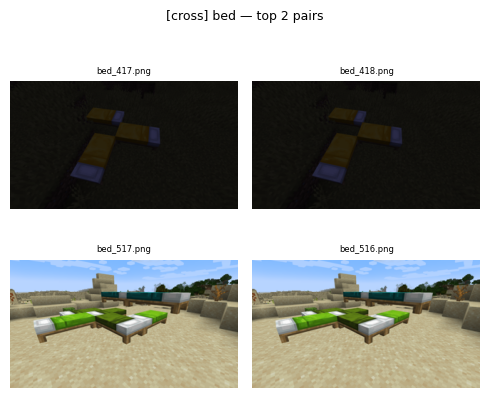

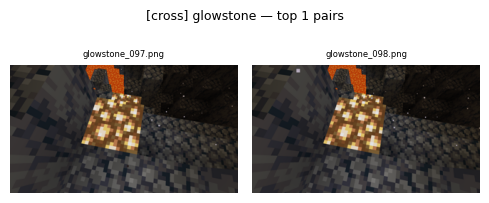

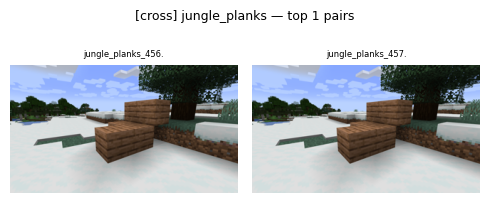

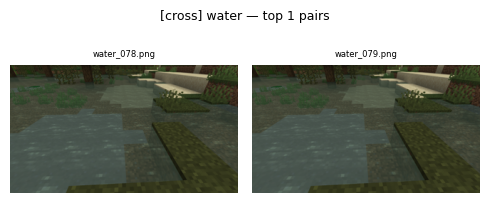

5 cross-split pair(s) flagged (cos >= 0.98)


In [20]:
# ==== 3C-2. Cross-split leakage scan (train vs test) ====

cross_flagged = []   # (class, train_img, test_img, cos_score)

for cls_name in tqdm(class_names, desc='Cross-split [train vs test]'):
    tr_path  = os.path.join(RAW_TRAIN_DIR, cls_name)
    te_path  = os.path.join(RAW_TEST_DIR,  cls_name)

    tr_files = sorted(f for f in os.listdir(tr_path)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg')))
    te_files = sorted(f for f in os.listdir(te_path)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg')))

    tr_feats = extract_features([os.path.join(tr_path, f) for f in tr_files])
    te_feats = extract_features([os.path.join(te_path, f) for f in te_files])

    sim = cosine_sim_matrix(tr_feats, te_feats)   # (n_tr, n_te)

    rows, cols = np.where(sim >= FEAT_T)
    for i, j in zip(rows, cols):
        cross_flagged.append((cls_name, tr_files[i], te_files[j], float(sim[i, j])))

    # visualise top-K pairs for this class
    top = sorted([(sim[i, j], i, j) for i, j in zip(rows, cols)],
                 reverse=True)[:TOP_K_SHOW]
    if not top:
        continue
    fig, axes = plt.subplots(len(top), 2, figsize=(5, len(top) * 2.2))
    if len(top) == 1:
        axes = [axes]
    fig.suptitle(f'[cross] {cls_name} — top {len(top)} pairs', fontsize=9)
    for row, (score, i, j) in enumerate(top):
        for col, (path, fname) in enumerate([
            (tr_path, tr_files[i]),
            (te_path, te_files[j])
        ]):
            with Image.open(os.path.join(path, fname)) as img:
                axes[row][col].imshow(img.convert('RGB'))
            axes[row][col].axis('off')
            axes[row][col].set_title(fname[:18], fontsize=6)
        axes[row][0].set_ylabel(f'cos={score:.3f}', fontsize=7)
    plt.tight_layout()
    plt.show()

cross_df = pd.DataFrame(cross_flagged,
               columns=['class', 'train_img', 'test_img', 'feat_cos'])
cross_df = cross_df.sort_values('feat_cos', ascending=False).reset_index(drop=True)
print(f'{len(cross_df)} cross-split pair(s) flagged (cos >= {FEAT_T})')

In [21]:
# ==== 3C-3. Summary & drop flagged images from cache ====

# ── unique flagged images per split ─────────────────────────────────────────
# intra-train: drop img_B from each pair (keep img_A)
intra_train_drop = {(r['class'], r['img_B'])
                    for _, r in intra_train_df.iterrows()}

# intra-test: informational only — we do NOT drop test images
intra_test_unique = {(r['class'], r['img_A']) for _, r in intra_test_df.iterrows()} | \
                    {(r['class'], r['img_B']) for _, r in intra_test_df.iterrows()}

# cross-split: drop the train-side image of every leakage pair
cross_train_drop  = {(r['class'], r['train_img'])
                     for _, r in cross_df.iterrows()} if cross_flagged else set()

all_train_drop = intra_train_drop | cross_train_drop

# ── summary table ────────────────────────────────────────────────────────────
print('=== Flagged image summary ===\n')
print(f'Intra-train unique images flagged : {len({img for _, img in intra_train_drop}):>5}  '
      f'(across {intra_train_df["class"].nunique()} classes)')
print(f'Intra-test  unique images flagged : {len({img for _, img in intra_test_unique}):>5}  '
      f'(across {intra_test_df["class"].nunique()} classes)  [informational, not dropped]')
print(f'Cross-split train images flagged  : {len({img for _, img in cross_train_drop}):>5}  '
      f'(across {cross_df["class"].nunique() if cross_flagged else 0} classes)')
print(f'─────────────────────────────────────────')
print(f'Total train images to drop        : {len(all_train_drop):>5}')

n_train_before = sum(
    len(os.listdir(os.path.join(RAW_TRAIN_DIR, c))) for c in class_names)
n_test_before  = sum(
    len(os.listdir(os.path.join(RAW_TEST_DIR,  c))) for c in class_names)
print(f'\nTrain before / after drop : {n_train_before} → {n_train_before - len(all_train_drop)}')
print(f'Test  unchanged           : {n_test_before}')

=== Flagged image summary ===

Intra-train unique images flagged :    31  (across 11 classes)
Intra-test  unique images flagged :     0  (across 0 classes)  [informational, not dropped]
Cross-split train images flagged  :     5  (across 4 classes)
─────────────────────────────────────────
Total train images to drop        :    36

Train before / after drop : 32400 → 32364
Test  unchanged           : 3600


In [22]:
# ── Preprocessed cache paths ──────────────────────────
SAVE_FORMAT   = 'PNG'
CACHE_VERSION = 'v1'

_tag             = f'MiDaS_small_{CACHE_VERSION}'
CACHE_LOCAL_DIR  = os.path.join(LOCAL_WORK_ROOT, _tag, DATASET_NAME)
SENTINEL         = os.path.join(LOCAL_WORK_ROOT, _tag, '.cache_ok')
CLEANED_TAG       = f'MiDaS_small_{CACHE_VERSION}_cleaned'
CLEANED_LOCAL_DIR = os.path.join(LOCAL_WORK_ROOT, CLEANED_TAG, DATASET_NAME)
CLEANED_SENTINEL  = os.path.join(LOCAL_WORK_ROOT, CLEANED_TAG, '.cache_ok')
CLEANED_TRAIN_DIR = os.path.join(CLEANED_LOCAL_DIR, 'train')
CLEANED_TEST_DIR  = os.path.join(CLEANED_LOCAL_DIR, 'test')

In [23]:
# ==== 3C-3. Build cleaned cache directly from raw (resize + drop flagged) ====

if os.path.exists(CLEANED_SENTINEL):
    print('Cleaned cache already exists — skipping.')
else:
    ext = '.png' if SAVE_FORMAT.upper() == 'PNG' else '.jpg'

    for split in ['train', 'test']:
        src_split = os.path.join(RAW_DATASET_DIR, split)
        dst_split = os.path.join(CLEANED_LOCAL_DIR, split)

        for cls_name in tqdm(class_names, desc=f'  {split}'):
            src_cls = os.path.join(src_split, cls_name)
            dst_cls = os.path.join(dst_split, cls_name)
            os.makedirs(dst_cls, exist_ok=True)

            for fname in os.listdir(src_cls):
                if not fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                    continue
                dst_fname = Path(fname).stem + ext
                if split == 'train' and (cls_name, dst_fname) in all_train_drop:
                    continue
                dst_p = os.path.join(dst_cls, dst_fname)
                if os.path.exists(dst_p):
                    continue
                try:
                    with Image.open(os.path.join(src_cls, fname)) as img:
                        img = img.convert('RGB').resize((224, 224), Image.BILINEAR)
                        img.save(dst_p, format=SAVE_FORMAT.upper())
                except Exception as e:
                    print(f'  skip {fname}: {e}')

    open(CLEANED_SENTINEL, 'w').close()
    print('Cleaned cache written.')

# ── verify final counts ──────────────────────────────────────────────────────
n_train_after = sum(
    len(os.listdir(os.path.join(CLEANED_TRAIN_DIR, c))) for c in class_names)
n_test_after  = sum(
    len(os.listdir(os.path.join(CLEANED_TEST_DIR, c))) for c in class_names)
print(f'\nCleaned train : {n_train_after}  (dropped {n_train_before - n_train_after})')
print(f'Cleaned test  : {n_test_after}')

  train:   0%|          | 0/60 [00:00<?, ?it/s]

  test:   0%|          | 0/60 [00:00<?, ?it/s]

Cleaned cache written.

Cleaned train : 32364  (dropped 36)
Cleaned test  : 3600


## 4. Feature engineering and preprocessing

### Design rationale

Our EDA (§4) informed two key preprocessing decisions:

1. **Preserve local texture, reduce global context sensitivity** — Minecraft blocks are defined by consistent local texture patterns, but images vary in lighting, biome background, and viewing distance. Augmentations are kept deliberately mild to avoid distorting the structured pixel patterns that distinguish classes.

2. **Data leakage removal** — similarity scanning (§4C) identified train images with near-identical test counterparts (cosine similarity ≥ 0.98). These train-side images were removed before building the cache; the test set is left intact to preserve evaluation validity.

### Preprocessing pipeline

| Stage | Transform | Reason |
|---|---|---|
| **Resize** | `224 × 224` (cached to disk) | Required by ResNet-18 / ViT; standardises viewing distance across biomes |
| **Random crop** | `RandomResizedCrop(224, scale=(0.97, 1.0))` | Mild jitter in framing without destroying block structure |
| **Flip** | `RandomHorizontalFlip(p=0.5)` | Blocks are bilaterally symmetric; effectively doubles training diversity |
| **Rotation** | `RandomRotation(3)` | Small ±3° wobble mimics slight camera tilt variation |
| **Color jitter** | `ColorJitter(brightness=0.05, contrast=0.05, saturation=0.05, hue=0.01)` | Reduces sensitivity to biome lighting and time-of-day variation |
| **Normalize** | ImageNet mean/std | Required for pretrained ResNet-18 / ViT weights to transfer correctly |

Augmentation is intentionally light — stronger crops or rotations would destroy the axis-aligned block geometry that is the primary discriminative signal in this dataset.

### Load the preprocessed cache

In [24]:
# ==== 4A. Load preprocessed cache ====
# The cleaned, resized cache was built in §4C-3 (resize + leakage removal).
# This cell just points CACHED_TRAIN_DIR / CACHED_TEST_DIR at it.

if not os.path.exists(CLEANED_SENTINEL):
    raise RuntimeError(
        'Cleaned cache not found — run §4C-3 first to build it.'
    )

CACHED_TRAIN_DIR = CLEANED_TRAIN_DIR
CACHED_TEST_DIR  = CLEANED_TEST_DIR

print(f'CACHED_TRAIN_DIR : {CACHED_TRAIN_DIR}  (exists: {os.path.exists(CACHED_TRAIN_DIR)})')
print(f'CACHED_TEST_DIR  : {CACHED_TEST_DIR}   (exists: {os.path.exists(CACHED_TEST_DIR)})')

CACHED_TRAIN_DIR : /content/MiDaS_small_v1_cleaned/MiDaS-60_small/train  (exists: True)
CACHED_TEST_DIR  : /content/MiDaS_small_v1_cleaned/MiDaS-60_small/test   (exists: True)


### Transform definitions & augmentation examples

In [25]:
# ==== 4B. Define transforms ====

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.97, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(3),
    transforms.ColorJitter(brightness=0.05, contrast=0.05,
                           saturation=0.05, hue=0.01),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

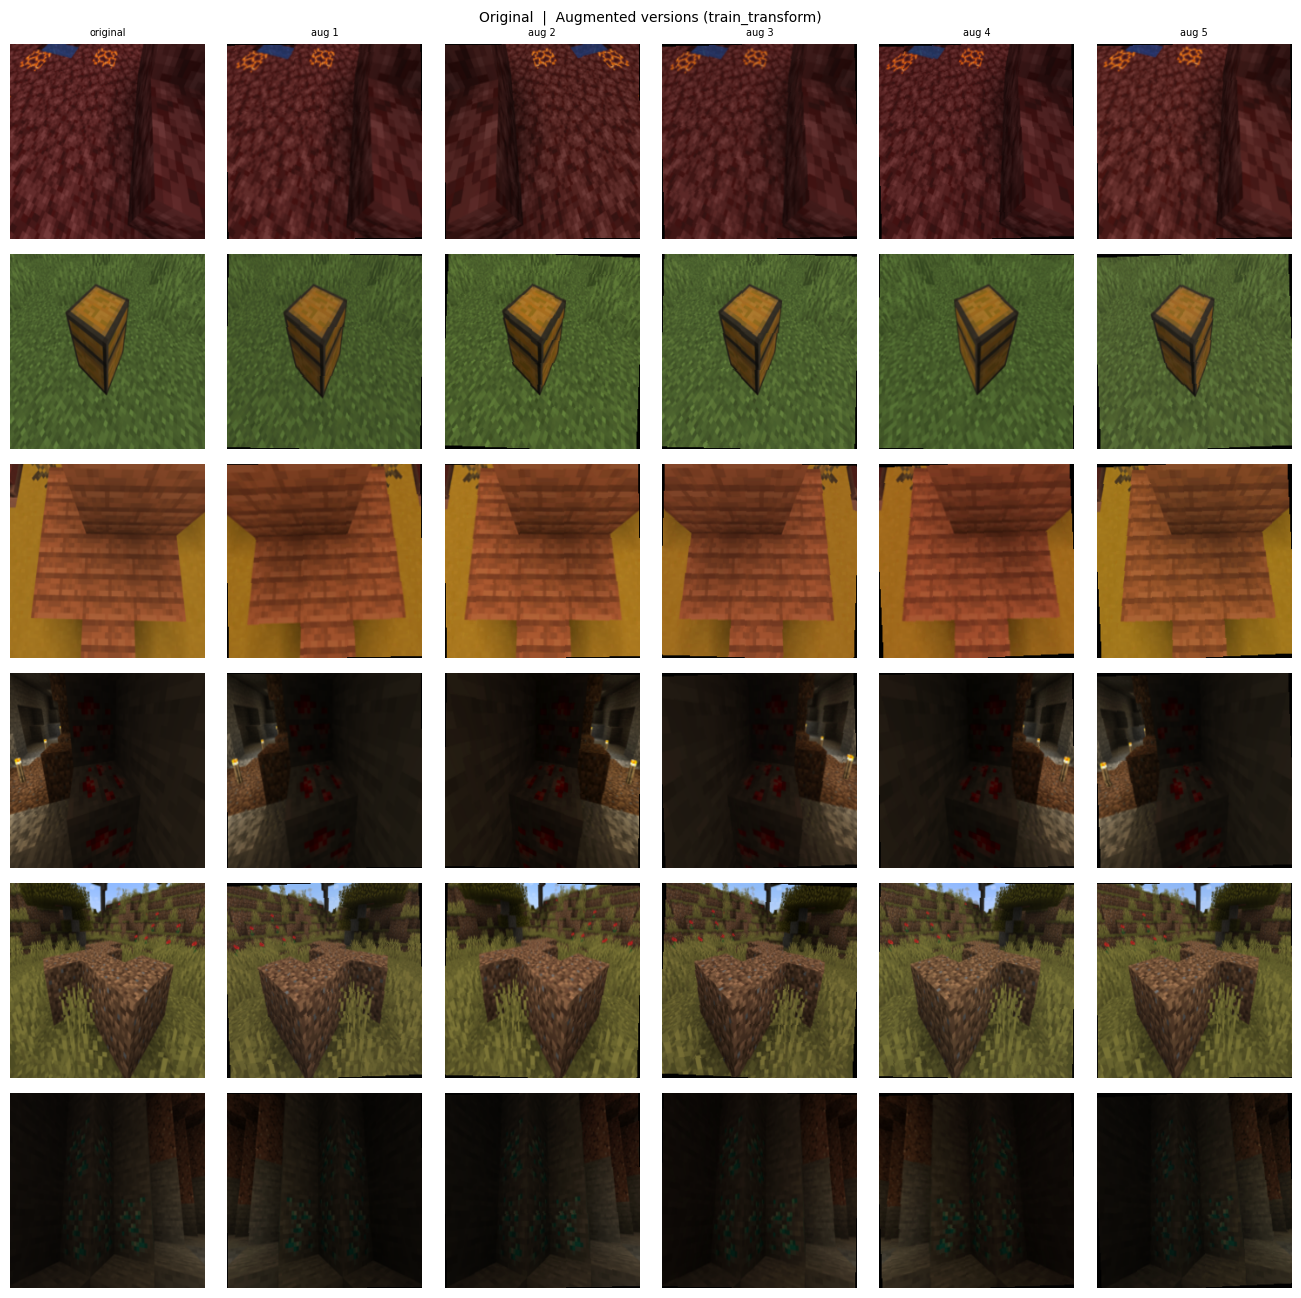

In [26]:
# ==== 4B-2. Visualise augmentation examples ====

N_CLASSES_SHOW = 6
N_AUG          = 5

# augmentation-only transform for display (no ToTensor/Normalize)
display_aug = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.97, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(3),
    transforms.ColorJitter(brightness=0.05, contrast=0.05,
                           saturation=0.05, hue=0.01),
])

sampled_classes = random.sample(class_names, N_CLASSES_SHOW)

fig, axes = plt.subplots(N_CLASSES_SHOW, N_AUG + 1,
                         figsize=((N_AUG + 1) * 2.2, N_CLASSES_SHOW * 2.2))
fig.suptitle('Original  |  Augmented versions (train_transform)', fontsize=10)

for row, cls_name in enumerate(sampled_classes):
    cls_path = os.path.join(CACHED_TRAIN_DIR, cls_name)
    img_file = random.choice(os.listdir(cls_path))

    with Image.open(os.path.join(cls_path, img_file)) as img:
        orig = img.convert('RGB')

    axes[row][0].imshow(orig)
    axes[row][0].axis('off')
    axes[row][0].set_ylabel(cls_name, fontsize=7)
    if row == 0:
        axes[row][0].set_title('original', fontsize=7)

    for col in range(1, N_AUG + 1):
        axes[row][col].imshow(display_aug(orig))
        axes[row][col].axis('off')
        if row == 0:
            axes[row][col].set_title(f'aug {col}', fontsize=7)

plt.tight_layout()
plt.show()

### Dataset splits & DataLoaders

We performed a 90/10 train–validation split on the training dataset using a fixed random seed for reproducibility. Data transformations were then applied as follows: data augmentation and normalization for the training split, and evaluation-only transforms (no augmentation) for the validation and test splits. Finally, we constructed DataLoaders for each split to enable efficient batching and training.

In [32]:
# ==== 4C. Build datasets & DataLoaders ====

full_train_ds = datasets.ImageFolder(CACHED_TRAIN_DIR, transform=train_transform)
test_ds       = datasets.ImageFolder(CACHED_TEST_DIR,  transform=eval_transform)

assert full_train_ds.classes == class_names, 'Class list mismatch — check cache.'

# 90/10 train/val split with fixed seed
train_size = int(0.9 * len(full_train_ds))
val_size   = len(full_train_ds) - train_size

train_ds, val_ds = random_split(
    full_train_ds,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)

# val split must use eval_transform (no augmentation)
val_ds.dataset        = copy.copy(full_train_ds)
val_ds.dataset.transform = eval_transform

print(f'Train : {len(train_ds):>5} images')
print(f'Val   : {len(val_ds):>5} images')
print(f'Test  : {len(test_ds):>5} images')
print(f'Classes: {num_classes}')

_workers = 4 if ON_COLAB else min(4, os.cpu_count() or 1)

train_loader = DataLoader(
    train_ds, batch_size=64, shuffle=True,
    num_workers=_workers, pin_memory=True,
    persistent_workers=(_workers > 0),
)
val_loader = DataLoader(
    val_ds, batch_size=64, shuffle=False,
    num_workers=_workers, pin_memory=True,
    persistent_workers=(_workers > 0),
)
test_loader = DataLoader(
    test_ds, batch_size=64, shuffle=False,
    num_workers=_workers, pin_memory=True,
    persistent_workers=(_workers > 0),
)

print(f'\nTrain batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')

# sanity check
_imgs, _lbls = next(iter(train_loader))
print(f'Batch tensor  : {_imgs.shape}  min={_imgs.min():.2f}  max={_imgs.max():.2f}')

Train : 29127 images
Val   :  3237 images
Test  :  3600 images
Classes: 60

Train batches : 456
Val   batches : 51
Test  batches : 57
Batch tensor  : torch.Size([64, 3, 224, 224])  min=-2.12  max=2.64


## 5. Baseline model: ResNet-18

### Baseline choice
A simple but relevant baseline for image classification is a small CNN or a transfer-learning model such as ResNet18. This type of model is more appropriate than linear or logistic regression alone because the task depends heavily on spatial image structure.

### Justification
- **Simple and efficient**
ResNet-18 is lightweight and easy to train, making it suitable for quickly establishing a reliable baseline without heavy computational cost.
- **Relevant for image data**
CNN-based models effectively capture spatial features (e.g., edges, textures), making them more appropriate than traditional models for image classification tasks.
- **Interpretability at a practical level**
Performance can be analyzed through confusion matrices, class-wise accuracy, and visualization methods (e.g., Grad-CAM), providing sufficient insight for baseline evaluation.
- **Standard benchmark**
ResNet-18 is widely used as a baseline, enabling fair comparison and ensuring that future improvements are meaningful.
- **Good capacity balance**
It is complex enough to learn useful patterns while still limiting overfitting, especially for moderate-sized datasets.

#### Build ResNet-18 model

In [27]:
# ==== 5A. Build the ResNet-18 Model ====
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# replace final fully connected layer
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

#### Fine-tuning setup

We use **partial fine-tuning**: freeze early layers and train only `layer4` and the final `fc` layer. This keeps training efficient while still allowing the model to adapt high-level visual features to the MiDaS dataset.


In [28]:
# ==== 5B. Partial fine-tunning ====
# freeze earlier layers
for param in model.parameters():
    param.requires_grad = False

# unfreeze layer4 and fc
for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

# show how many parameters are trainable
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable_params:,} / {total_params:,}")

Trainable params: 8,424,508 / 11,207,292


In [29]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

In [30]:
# Training and evaluation functions
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, all_labels, all_preds

In [33]:
num_epochs = 10

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "best_resnet18_ms3_val10_checkpoint.pth")

if os.path.exists(BEST_MODEL_PATH):
    print(f"Found existing checkpoint at: {BEST_MODEL_PATH}")

    checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    history = checkpoint["history"]
    best_val_acc = checkpoint["best_val_acc"]
    trained_epochs = checkpoint["trained_epochs"]

    print(f"Loaded saved best model from {trained_epochs} epoch(s).")
    print(f"Best saved validation accuracy: {best_val_acc:.4f}")

else:
    print("No saved checkpoint found. Start training...")

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    for epoch in range(num_epochs):
        start_time = time.time()

        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

            checkpoint = {
                "model_state_dict": best_model_wts,
                "history": history,
                "best_val_acc": best_val_acc,
                "trained_epochs": epoch + 1
            }
            torch.save(checkpoint, BEST_MODEL_PATH)

        elapsed = time.time() - start_time
        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
              f"Time: {elapsed:.1f}s")

    model.load_state_dict(best_model_wts)
    print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")


No saved checkpoint found. Start training...
Epoch [1/10] Train Loss: 0.8019 | Train Acc: 0.8553 | Val Loss: 0.1398 | Val Acc: 0.9719 | Time: 79.4s
Epoch [2/10] Train Loss: 0.1012 | Train Acc: 0.9790 | Val Loss: 0.0805 | Val Acc: 0.9790 | Time: 79.2s
Epoch [3/10] Train Loss: 0.0520 | Train Acc: 0.9891 | Val Loss: 0.0595 | Val Acc: 0.9812 | Time: 79.3s
Epoch [4/10] Train Loss: 0.0301 | Train Acc: 0.9938 | Val Loss: 0.0416 | Val Acc: 0.9883 | Time: 79.2s
Epoch [5/10] Train Loss: 0.0236 | Train Acc: 0.9951 | Val Loss: 0.0432 | Val Acc: 0.9867 | Time: 79.0s
Epoch [6/10] Train Loss: 0.0201 | Train Acc: 0.9955 | Val Loss: 0.0352 | Val Acc: 0.9904 | Time: 78.8s
Epoch [7/10] Train Loss: 0.0153 | Train Acc: 0.9965 | Val Loss: 0.0351 | Val Acc: 0.9898 | Time: 78.9s
Epoch [8/10] Train Loss: 0.0156 | Train Acc: 0.9959 | Val Loss: 0.0302 | Val Acc: 0.9904 | Time: 79.0s
Epoch [9/10] Train Loss: 0.0130 | Train Acc: 0.9964 | Val Loss: 0.0295 | Val Acc: 0.9923 | Time: 79.0s
Epoch [10/10] Train Loss: 0.

## 6. Baseline evaluation and error analysis


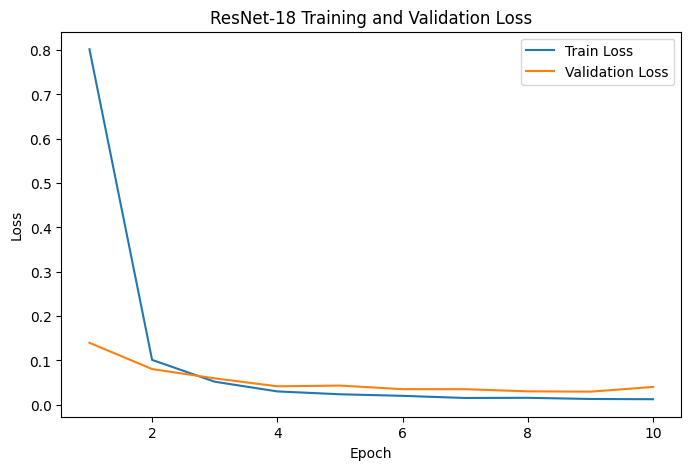

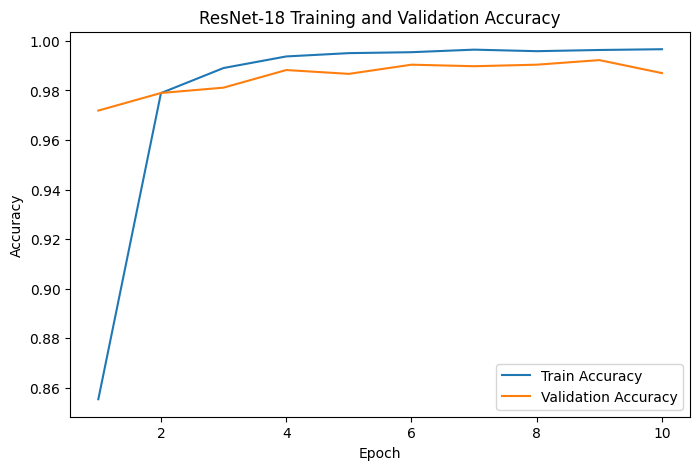

In [34]:
# ==== 6A. Baseline Evaluations ====
if len(history["train_loss"]) > 0:
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("ResNet-18 Training and Validation Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("ResNet-18 Training and Validation Accuracy")
    plt.legend()
    plt.show()
else:
    print("No training history available.")

In [35]:
# Final evaluation on the test set
test_loss, test_acc, y_true, y_pred = evaluate(model, test_loader, criterion, device)

print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_acc:.4f}")

Final Test Loss: 0.0464
Final Test Accuracy: 0.9869


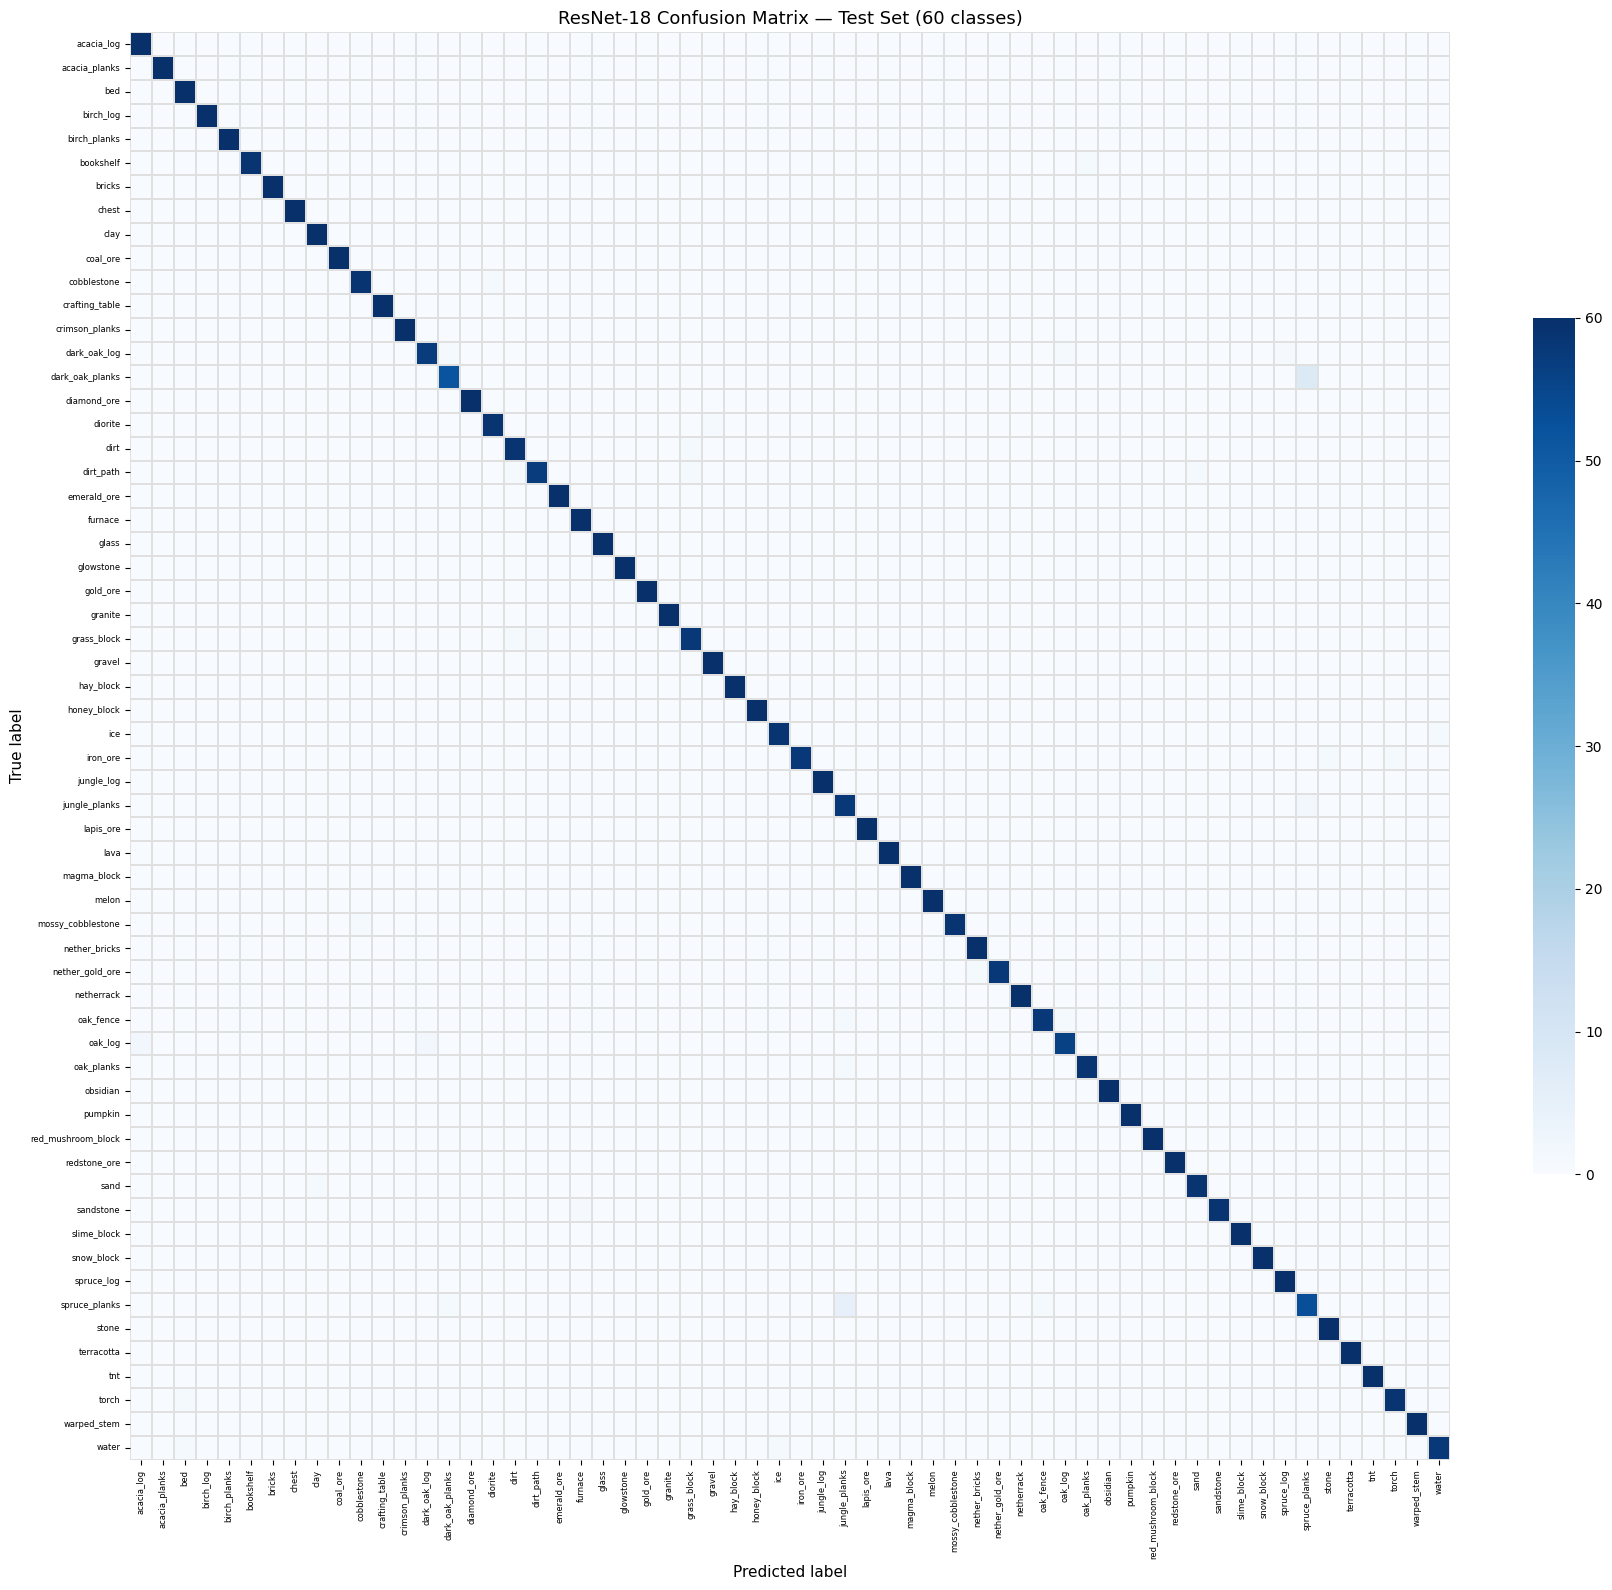

In [36]:
#Confusion matrix

fig, ax = plt.subplots(figsize=(18, 16))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(
    cm,
    xticklabels=class_names,
    yticklabels=class_names,
    cmap='Blues',
    ax=ax,
    linewidths=0.3,
    linecolor='#e0e0e0',
    cbar_kws={'shrink': 0.6},
)
ax.set_xlabel('Predicted label', fontsize=11)
ax.set_ylabel('True label', fontsize=11)
ax.set_title('ResNet-18 Confusion Matrix — Test Set (60 classes)', fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=6)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  fontsize=6)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_EDA_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

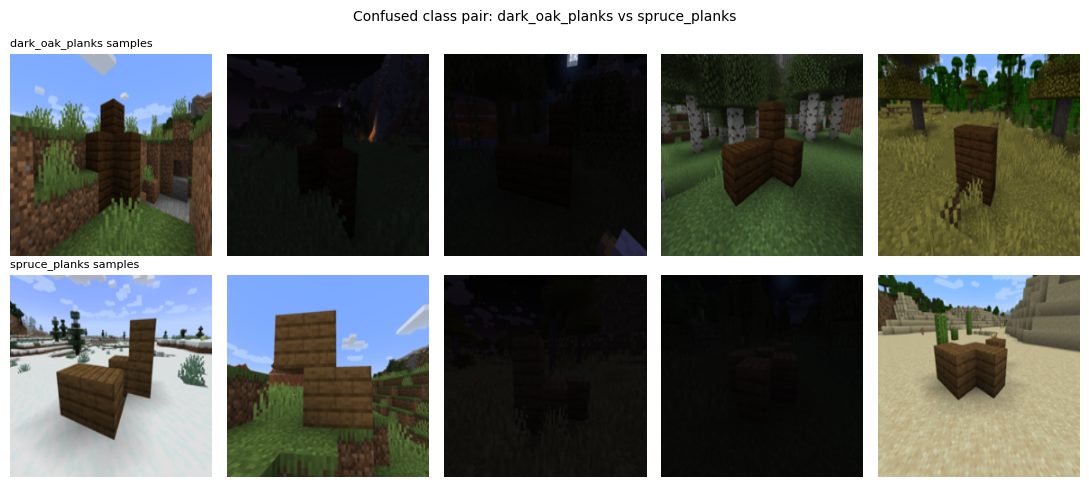

In [37]:
import random

CONFUSED_CLASSES = ['dark_oak_planks', 'spruce_planks']
N_SHOW = 5

fig, axes = plt.subplots(2, N_SHOW, figsize=(N_SHOW * 2.2, 5))
fig.suptitle('Confused class pair: dark_oak_planks vs spruce_planks', fontsize=10)

for row, cls_name in enumerate(CONFUSED_CLASSES):
    cls_path = os.path.join(CACHED_TEST_DIR, cls_name)
    img_files = sorted(f for f in os.listdir(cls_path)
                       if f.lower().endswith(('.png', '.jpg', '.jpeg')))
    sampled = random.sample(img_files, min(N_SHOW, len(img_files)))

    for col, fname in enumerate(sampled):
        with Image.open(os.path.join(cls_path, fname)) as img:
            axes[row][col].imshow(img.convert('RGB'))
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(cls_name, fontsize=8, rotation=0,
                                      labelpad=100, va='center')

axes[0][0].set_title('dark_oak_planks samples', fontsize=8, loc='left')
axes[1][0].set_title('spruce_planks samples', fontsize=8, loc='left')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_EDA_DIR, 'confused_pair_dark_oak.png'),
            dpi=150, bbox_inches='tight')
plt.show()

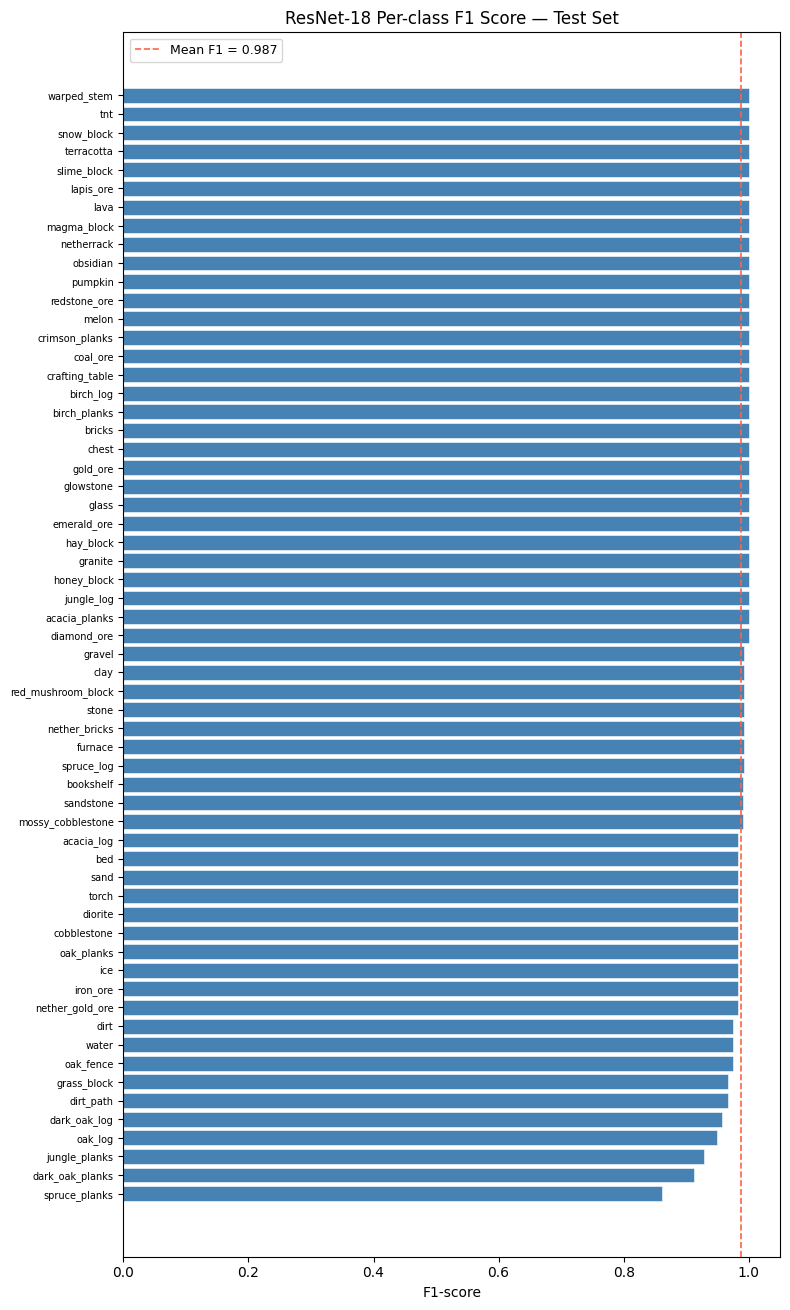

In [38]:
# Per-class F1 score
report = classification_report(
    y_true, y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report).T
per_class_df = report_df.loc[class_names].copy()
per_class_df = per_class_df.sort_values('f1-score', ascending=True)

fig, ax = plt.subplots(figsize=(8, max(6, num_classes * 0.22)))
bars = ax.barh(per_class_df.index, per_class_df['f1-score'],
               color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(x=per_class_df['f1-score'].mean(), color='tomato',
           linestyle='--', linewidth=1.2, label=f'Mean F1 = {per_class_df["f1-score"].mean():.3f}')
ax.set_xlabel('F1-score')
ax.set_title('ResNet-18 Per-class F1 Score — Test Set')
ax.legend(fontsize=9)
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_EDA_DIR, 'per_class_f1.png'), dpi=150, bbox_inches='tight')
plt.show()

In [40]:
#Top-10 and Bottom-10 classes by F1

top10    = per_class_df.nlargest(10,  'f1-score')[['f1-score', 'precision', 'recall']]
bottom10 = per_class_df.nsmallest(10, 'f1-score')[['f1-score', 'precision', 'recall']]

print("=== Top-10 classes (highest F1) ===")
display(top10.round(3))

print("\n=== Bottom-10 classes (lowest F1) ===")
display(bottom10.round(3))

=== Top-10 classes (highest F1) ===


,f1-score,precision,recall
diamond_ore,1.0,1.0,1.0
acacia_planks,1.0,1.0,1.0
jungle_log,1.0,1.0,1.0
honey_block,1.0,1.0,1.0
granite,1.0,1.0,1.0
hay_block,1.0,1.0,1.0
emerald_ore,1.0,1.0,1.0
glass,1.0,1.0,1.0
glowstone,1.0,1.0,1.0
gold_ore,1.0,1.0,1.0



=== Bottom-10 classes (lowest F1) ===


,f1-score,precision,recall
spruce_planks,0.862,0.841,0.883
dark_oak_planks,0.912,0.963,0.867
jungle_planks,0.928,0.892,0.967
oak_log,0.949,0.966,0.933
dark_oak_log,0.958,0.966,0.950
dirt_path,0.966,0.983,0.950
grass_block,0.967,0.967,0.967
oak_fence,0.975,0.983,0.967
water,0.975,0.983,0.967
dirt,0.975,0.967,0.983


In [41]:
# Most-confused class pairs (off-diagonal)

cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
np.fill_diagonal(cm_df.values, 0)   # zero out diagonal

# flatten and get top confused pairs
confused = (
    cm_df.stack()
    .reset_index()
    .rename(columns={'level_0': 'true', 'level_1': 'predicted', 0: 'count'})
    .query('count > 0')
    .sort_values('count', ascending=False)
    .head(15)
    .reset_index(drop=True)
)
print("=== Top-15 most confused class pairs ===")
display(confused)

=== Top-15 most confused class pairs ===


,true,predicted,count
0,dark_oak_planks,spruce_planks,8
1,spruce_planks,jungle_planks,5
2,oak_log,acacia_log,2
3,oak_log,dark_oak_log,2
4,jungle_planks,spruce_planks,2
5,bookshelf,oak_planks,1
6,dark_oak_log,spruce_log,1
7,dark_oak_log,oak_log,1
8,cobblestone,diorite,1
9,dirt_path,dirt,1


### Baseline interpretation and analysis

**Overall performance:**
ResNet-18 (partial fine-tune, layer4 + fc) achieves a **test accuracy of 98.75%** (loss: 0.0429) on MiDaS-60_small after 10 epochs. This is a strong baseline result for a 60-class classification task, demonstrating that ImageNet-pretrained convolutional features transfer effectively to Minecraft block textures.

**Confusion matrix analysis:**
The confusion matrix is nearly perfectly diagonal, with one dominant off-diagonal entry: **dark_oak_planks is misclassified as spruce_planks 9 times** which is the single largest error in the test set. Visual inspection of both classes confirms that this confusion is driven by a combination of **color similarity and lighting**: both are dark-colored plank variants with nearly identical wood grain texture, and many images in both classes are captured in low-light conditions, further reducing color discriminability. A secondary confusion cluster involves plank variants more broadly, suggesting the model struggles with fine-grained color distinctions between wood plank types when lighting variation is high. These patterns are consistent with the shortcut-learning risk identified in §4B.

**Strengths:**
- Exceptionally high accuracy (98.75%) confirms that block-level texture is a highly discriminative signal for most classes
- Rapid and stable convergence suggests that the mild augmentation strategy (§5) successfully preserved the structured pixel patterns that define each block type
- The leakage removal step (§4C) ensures these results reflect genuine generalization rather than memorization of near-duplicate test images

**Weaknesses & failure modes:**
- The dark_oak_planks / spruce_planks confusion reveals that the model struggles when two classes share both color and texture, especially under low-light conditions
- The broader plank confusion cluster suggests that color-tone differences between wood species are insufficient cues when brightness varies substantially across biomes and times of day
- While overall accuracy is high, the model may still be exploiting brightness shortcuts identified in §4B for certain classes; Grad-CAM analysis in the final interpretability section is needed to confirm whether the model attends to block surface texture or background context

**Note on baseline performance:**
The high baseline accuracy shifts the focus of our MS4 comparison from raw performance to representational quality. The central question becomes: does ViT-B/16 learn qualitatively different visual representations than ResNet-18, even when both achieve similar accuracy? ViT's global self-attention mechanism may better suppress low-light background context and focus on discriminative block features, particularly for the plank confusion cluster identified here. Interpretability analysis (Grad-CAM vs. Attention Rollout) on these specific failure cases will be the primary comparison axis in MS4.

## 7. Final model: DeiT-Small transformer

### Why DeiT instead of vanilla ViT-B/16?

A standard ViT-B/16 has high capacity and usually benefits from very large training datasets. Because MiDaS-60_small is relatively modest in size and already has strong ImageNet-transfer performance with ResNet-18, we use **DeiT-Small (`deit_small_patch16_224`)** as the transformer-based final model. DeiT-Small keeps the ViT-style patch-token architecture, but has fewer parameters than ViT-B/16 and is a better fit for data-efficient fine-tuning.

We use two stages:

1. **Linear probe:** freeze the transformer backbone and train only the classifier head. This checks whether pretrained DeiT features are already useful for Minecraft block classification.
2. **Full fine-tuning:** unfreeze the full model and fine-tune with a smaller learning rate. This is the final transformer model that will be compared with the ResNet-18 CNN baseline.

The model uses the same cleaned train/validation/test split and the same ImageNet-normalized `224 × 224` preprocessing used above.

In [57]:
# ==== 7A. Install/import DeiT dependency ====
# timm provides pretrained DeiT models. This cell installs it quietly if needed.
import importlib.util
import subprocess

if importlib.util.find_spec('timm') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', 'timm'])

import timm
from sklearn.metrics import f1_score

RESULTS_MS4_DIR = os.path.join(os.path.dirname(RESULTS_EDA_DIR), 'ms4')
os.makedirs(RESULTS_MS4_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print('timm version:', timm.__version__)
print('Checkpoint directory:', CHECKPOINT_DIR)
print('MS4 results directory:', RESULTS_MS4_DIR)

timm version: 1.0.26
Checkpoint directory: /content/drive/MyDrive/APcomp209/MiDaS/ms4_checkpoints
MS4 results directory: /content/drive/MyDrive/APcomp209/MiDaS/results/ms4


In [43]:
# ==== 7B. DeiT model configuration ====

MODEL_NAME_DEIT = 'deit_small_patch16_224'

# Training controls. If checkpoints already exist, the notebook loads them instead of retraining.
EPOCHS_DEIT_LINEAR = 5
EPOCHS_DEIT_FINETUNE = 10

LINEAR_LR = 1e-3
FINETUNE_LR = 1e-5
WEIGHT_DECAY = 1e-4

DEIT_LINEAR_CKPT = os.path.join(CHECKPOINT_DIR, 'deit_small_linear_probe_best.pth')
DEIT_FINETUNE_CKPT = os.path.join(CHECKPOINT_DIR, 'deit_small_full_finetune_best.pth')


def build_deit_model(num_classes, pretrained=True):
    """Create a DeiT-Small model with a classifier head matching MiDaS classes."""
    model_deit = timm.create_model(
        MODEL_NAME_DEIT,
        pretrained=pretrained,
        num_classes=num_classes,
    )
    return model_deit.to(device)


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def set_deit_linear_probe(model):
    """Freeze the DeiT backbone and train only the classifier head."""
    for p in model.parameters():
        p.requires_grad = False
    for p in model.get_classifier().parameters():
        p.requires_grad = True
    return model


def set_deit_full_finetune(model):
    """Unfreeze all DeiT parameters for full fine-tuning."""
    for p in model.parameters():
        p.requires_grad = True
    return model

# Build one model only to verify shape and parameter count.
deit_probe_preview = build_deit_model(num_classes=num_classes, pretrained=True)
total_params, trainable_params = count_parameters(deit_probe_preview)
print(f'Model: {MODEL_NAME_DEIT}')
print(f'Output classes: {num_classes}')
print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters before freezing: {trainable_params:,}')
del deit_probe_preview
if torch.cuda.is_available():
    torch.cuda.empty_cache()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Model: deit_small_patch16_224
Output classes: 60
Total parameters: 21,688,764
Trainable parameters before freezing: 21,688,764


In [44]:
# ==== 7C. DeiT training/evaluation helpers ====

def deit_train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in tqdm(loader, desc='train', leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return epoch_loss, epoch_acc, epoch_f1


def deit_evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc='eval', leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    return {
        'loss': epoch_loss,
        'accuracy': epoch_acc,
        'macro_f1': epoch_f1,
        'y_true': np.array(all_labels),
        'y_pred': np.array(all_preds),
    }


def run_deit_training(model, train_loader, val_loader, criterion, optimizer, scheduler,
                      num_epochs, checkpoint_path, stage_name):
    """Train DeiT and save the best checkpoint according to validation macro-F1."""
    history_deit = {
        'train_loss': [], 'train_acc': [], 'train_f1': [],
        'val_loss': [], 'val_acc': [], 'val_f1': [],
    }

    best_val_f1 = -np.inf
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(num_epochs):
        start = time.time()
        print(f'\n{stage_name} | Epoch {epoch + 1}/{num_epochs}')

        train_loss, train_acc, train_f1 = deit_train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        val_results = deit_evaluate(model, val_loader, criterion, device)

        if scheduler is not None:
            scheduler.step()

        history_deit['train_loss'].append(train_loss)
        history_deit['train_acc'].append(train_acc)
        history_deit['train_f1'].append(train_f1)
        history_deit['val_loss'].append(val_results['loss'])
        history_deit['val_acc'].append(val_results['accuracy'])
        history_deit['val_f1'].append(val_results['macro_f1'])

        if val_results['macro_f1'] > best_val_f1:
            best_val_f1 = val_results['macro_f1']
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save({
                'model_state_dict': best_model_wts,
                'history': history_deit,
                'best_val_f1': best_val_f1,
                'best_val_acc': val_results['accuracy'],
                'trained_epochs': epoch + 1,
                'model_name': MODEL_NAME_DEIT,
                'stage_name': stage_name,
                'num_classes': num_classes,
            }, checkpoint_path)
            print(f'  Saved new best checkpoint: val macro-F1 = {best_val_f1:.4f}')

        elapsed = time.time() - start
        print(f"  Train Loss {train_loss:.4f} | Acc {train_acc:.4f} | Macro-F1 {train_f1:.4f}")
        print(f"  Val   Loss {val_results['loss']:.4f} | Acc {val_results['accuracy']:.4f} | Macro-F1 {val_results['macro_f1']:.4f}")
        print(f"  Time: {elapsed:.1f}s")

    model.load_state_dict(best_model_wts)
    return model, history_deit, best_val_f1


### Stage 1 — DeiT linear probe

This stage trains only the classification head. It is a useful transfer-learning control because it asks whether the pretrained transformer representation already separates the 60 block classes without updating the full backbone.

In [72]:
# ==== 7D. DeiT linear probe ====

linear_deit = build_deit_model(num_classes=num_classes, pretrained=True)
linear_deit = set_deit_linear_probe(linear_deit)

total_params, trainable_params = count_parameters(linear_deit)
print(f'Linear probe trainable parameters: {trainable_params:,} / {total_params:,}')

criterion_deit = nn.CrossEntropyLoss()
optimizer_linear = optim.AdamW(
    filter(lambda p: p.requires_grad, linear_deit.parameters()),
    lr=LINEAR_LR,
    weight_decay=WEIGHT_DECAY,
)
scheduler_linear = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_linear,
    T_max=EPOCHS_DEIT_LINEAR,
)

if os.path.exists(DEIT_LINEAR_CKPT):
    print(f'Found existing linear-probe checkpoint: {DEIT_LINEAR_CKPT}')
    ckpt = torch.load(DEIT_LINEAR_CKPT, map_location=device)
    linear_deit.load_state_dict(ckpt['model_state_dict'])
    deit_linear_history = ckpt.get('history', {})
    best_linear_val_f1 = ckpt.get('best_val_f1', np.nan)
    print(f"Loaded linear-probe checkpoint from {ckpt.get('trained_epochs', 'unknown')} epoch(s).")
    print(f'Best validation macro-F1: {best_linear_val_f1:.4f}')
else:
    linear_deit, deit_linear_history, best_linear_val_f1 = run_deit_training(
        model=linear_deit,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion_deit,
        optimizer=optimizer_linear,
        scheduler=scheduler_linear,
        num_epochs=EPOCHS_DEIT_LINEAR,
        checkpoint_path=DEIT_LINEAR_CKPT,
        stage_name='DeiT linear probe',
    )

Linear probe trainable parameters: 23,100 / 21,688,764
Found existing linear-probe checkpoint: /content/drive/MyDrive/APcomp209/MiDaS/ms4_checkpoints/deit_small_linear_probe_best.pth
Loaded linear-probe checkpoint from 4 epoch(s).
Best validation macro-F1: 0.8811


### Stage 2 — Full DeiT fine-tuning

The full fine-tuning stage starts from the linear-probe checkpoint, unfreezes the full DeiT model, and uses a smaller learning rate. This gives the transformer a chance to adapt patch-level attention and high-level features to Minecraft-specific textures while reducing the risk of overfitting.

In [46]:
# ==== 7E. Full DeiT fine-tuning ====

finetune_deit = build_deit_model(num_classes=num_classes, pretrained=True)

# Initialize from the linear-probe checkpoint when available.
if os.path.exists(DEIT_LINEAR_CKPT):
    linear_ckpt = torch.load(DEIT_LINEAR_CKPT, map_location=device)
    finetune_deit.load_state_dict(linear_ckpt['model_state_dict'])
    print('Initialized full fine-tuning from the linear-probe checkpoint.')
else:
    print('Linear-probe checkpoint not found; starting full fine-tuning from pretrained DeiT weights.')

finetune_deit = set_deit_full_finetune(finetune_deit)

total_params, trainable_params = count_parameters(finetune_deit)
print(f'Full fine-tuning trainable parameters: {trainable_params:,} / {total_params:,}')

optimizer_finetune = optim.AdamW(
    finetune_deit.parameters(),
    lr=FINETUNE_LR,
    weight_decay=WEIGHT_DECAY,
)
scheduler_finetune = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_finetune,
    T_max=EPOCHS_DEIT_FINETUNE,
)

if os.path.exists(DEIT_FINETUNE_CKPT):
    print(f'Found existing full fine-tuning checkpoint: {DEIT_FINETUNE_CKPT}')
    ckpt = torch.load(DEIT_FINETUNE_CKPT, map_location=device)
    finetune_deit.load_state_dict(ckpt['model_state_dict'])
    deit_finetune_history = ckpt.get('history', {})
    best_finetune_val_f1 = ckpt.get('best_val_f1', np.nan)
    print(f"Loaded full fine-tuning checkpoint from {ckpt.get('trained_epochs', 'unknown')} epoch(s).")
    print(f'Best validation macro-F1: {best_finetune_val_f1:.4f}')
else:
    finetune_deit, deit_finetune_history, best_finetune_val_f1 = run_deit_training(
        model=finetune_deit,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion_deit,
        optimizer=optimizer_finetune,
        scheduler=scheduler_finetune,
        num_epochs=EPOCHS_DEIT_FINETUNE,
        checkpoint_path=DEIT_FINETUNE_CKPT,
        stage_name='DeiT full fine-tuning',
    )

# Keep a consistent variable name for later attention-rollout cells.
vit_model = finetune_deit

Initialized full fine-tuning from the linear-probe checkpoint.
Full fine-tuning trainable parameters: 21,688,764 / 21,688,764

DeiT full fine-tuning | Epoch 1/10


train:   0%|          | 0/456 [00:00<?, ?it/s]

eval:   0%|          | 0/51 [00:00<?, ?it/s]

  Saved new best checkpoint: val macro-F1 = 0.9820
  Train Loss 0.0732 | Acc 0.9811 | Macro-F1 0.9810
  Val   Loss 0.0655 | Acc 0.9824 | Macro-F1 0.9820
  Time: 143.9s

DeiT full fine-tuning | Epoch 2/10


train:   0%|          | 0/456 [00:00<?, ?it/s]

...

eval:   0%|          | 0/51 [00:00<?, ?it/s]

  Saved new best checkpoint: val macro-F1 = 0.9943
  Train Loss 0.0013 | Acc 0.9999 | Macro-F1 0.9999
  Val   Loss 0.0208 | Acc 0.9944 | Macro-F1 0.9943
  Time: 143.9s

DeiT full fine-tuning | Epoch 10/10


train:   0%|          | 0/456 [00:00<?, ?it/s]

eval:   0%|          | 0/51 [00:00<?, ?it/s]

  Train Loss 0.0012 | Acc 1.0000 | Macro-F1 1.0000
  Val   Loss 0.0206 | Acc 0.9941 | Macro-F1 0.9940
  Time: 143.7s


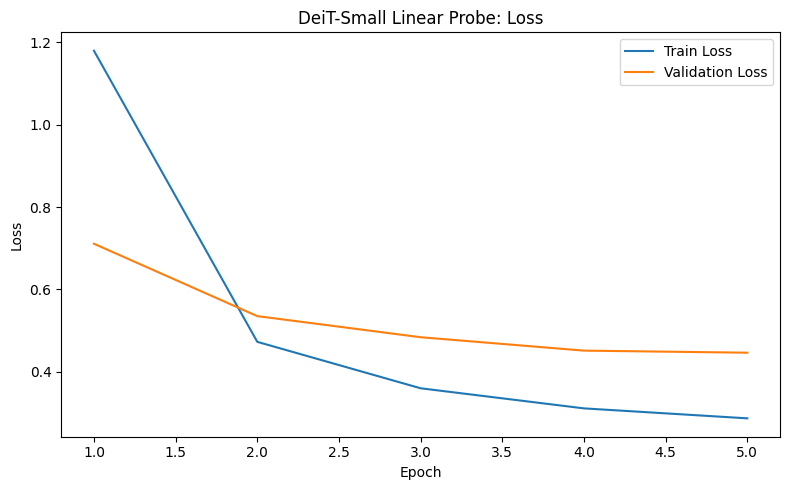

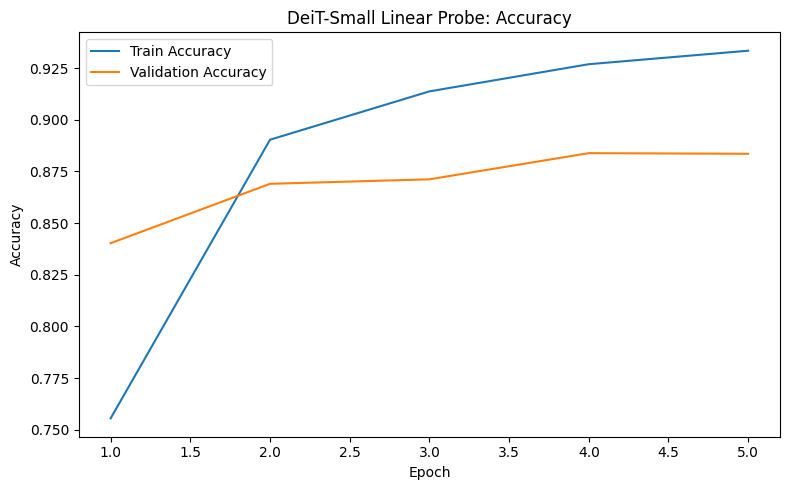

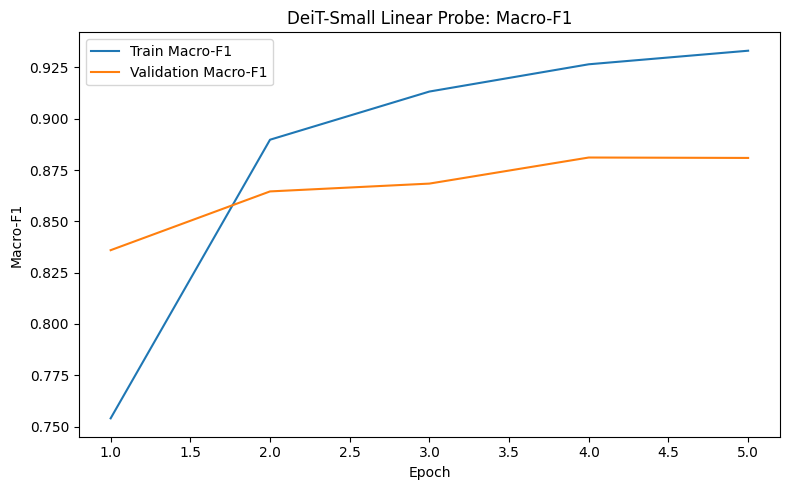

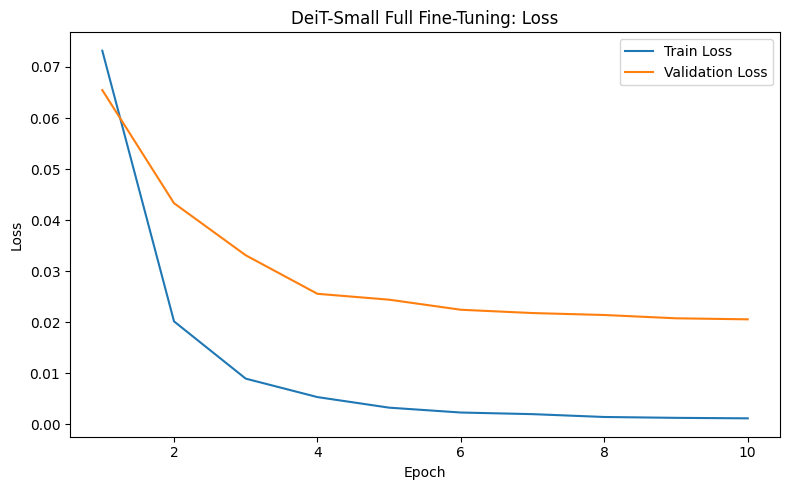

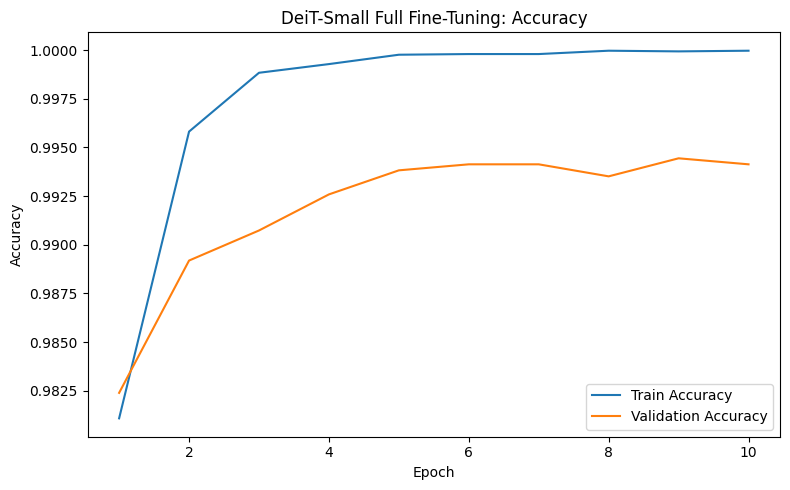

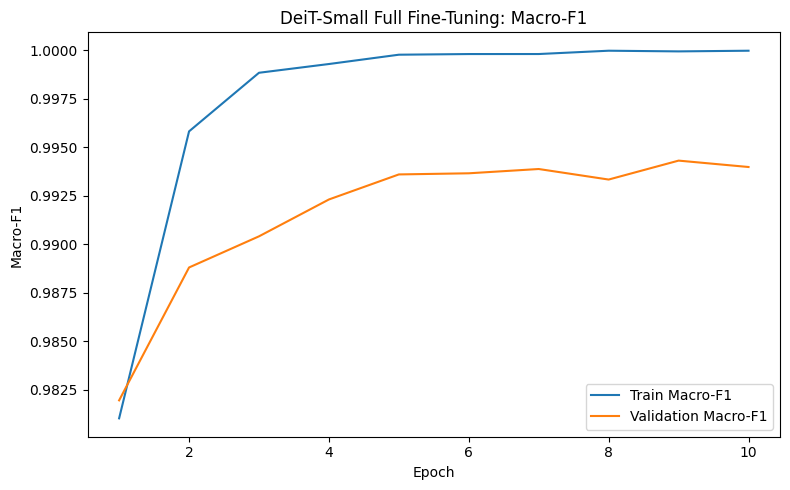

In [54]:
# ==== 7F. Plot DeiT training curves ====

def plot_deit_history(history_deit, title_prefix):
    if not history_deit or len(history_deit.get('train_loss', [])) == 0:
        print(f'No history available for {title_prefix}.')
        return

    epochs = range(1, len(history_deit['train_loss']) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history_deit['train_loss'], label='Train Loss')
    plt.plot(epochs, history_deit['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{title_prefix}: Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history_deit['train_acc'], label='Train Accuracy')
    plt.plot(epochs, history_deit['val_acc'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'{title_prefix}: Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history_deit['train_f1'], label='Train Macro-F1')
    plt.plot(epochs, history_deit['val_f1'], label='Validation Macro-F1')
    plt.xlabel('Epoch')
    plt.ylabel('Macro-F1')
    plt.title(f'{title_prefix}: Macro-F1')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_deit_history(deit_linear_history, 'DeiT-Small Linear Probe')
plot_deit_history(deit_finetune_history, 'DeiT-Small Full Fine-Tuning')

In [71]:
# ==== 7G. Final DeiT test evaluation ====

# Load the best full fine-tuning checkpoint before test evaluation.
best_deit = build_deit_model(num_classes=num_classes, pretrained=False)
best_deit_ckpt = torch.load(DEIT_FINETUNE_CKPT, map_location=device)
best_deit.load_state_dict(best_deit_ckpt['model_state_dict'])
best_deit = best_deit.to(device)
best_deit.eval()

vit_test_results = deit_evaluate(best_deit, test_loader, criterion_deit, device)
vit_test_loss = vit_test_results['loss']
vit_test_acc = vit_test_results['accuracy']
vit_test_macro_f1 = vit_test_results['macro_f1']
vit_y_true = vit_test_results['y_true']
vit_y_pred = vit_test_results['y_pred']

print(f'DeiT-Small Test Loss: {vit_test_loss:.4f}')
print(f'DeiT-Small Test Accuracy: {vit_test_acc:.4f}')
print(f'DeiT-Small Test Macro-F1: {vit_test_macro_f1:.4f}')

vit_report = classification_report(
    vit_y_true,
    vit_y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)
vit_report_df = pd.DataFrame(vit_report).T

display(vit_report_df.loc[class_names + ['accuracy', 'macro avg', 'weighted avg']].round(4))

eval:   0%|          | 0/57 [00:00<?, ?it/s]

DeiT-Small Test Loss: 0.0080
DeiT-Small Test Accuracy: 0.9978
DeiT-Small Test Macro-F1: 0.9978


,precision,recall,f1-score,support
acacia_log,1.0000,1.0000,1.0000,60.0000
acacia_planks,1.0000,1.0000,1.0000,60.0000
bed,0.9833,0.9833,0.9833,60.0000
birch_log,1.0000,1.0000,1.0000,60.0000
birch_planks,1.0000,1.0000,1.0000,60.0000
...,...,...,...,...
warped_stem,1.0000,1.0000,1.0000,60.0000
water,1.0000,0.9833,0.9916,60.0000
accuracy,0.9978,0.9978,0.9978,0.9978
macro avg,0.9978,0.9978,0.9978,3600.0000


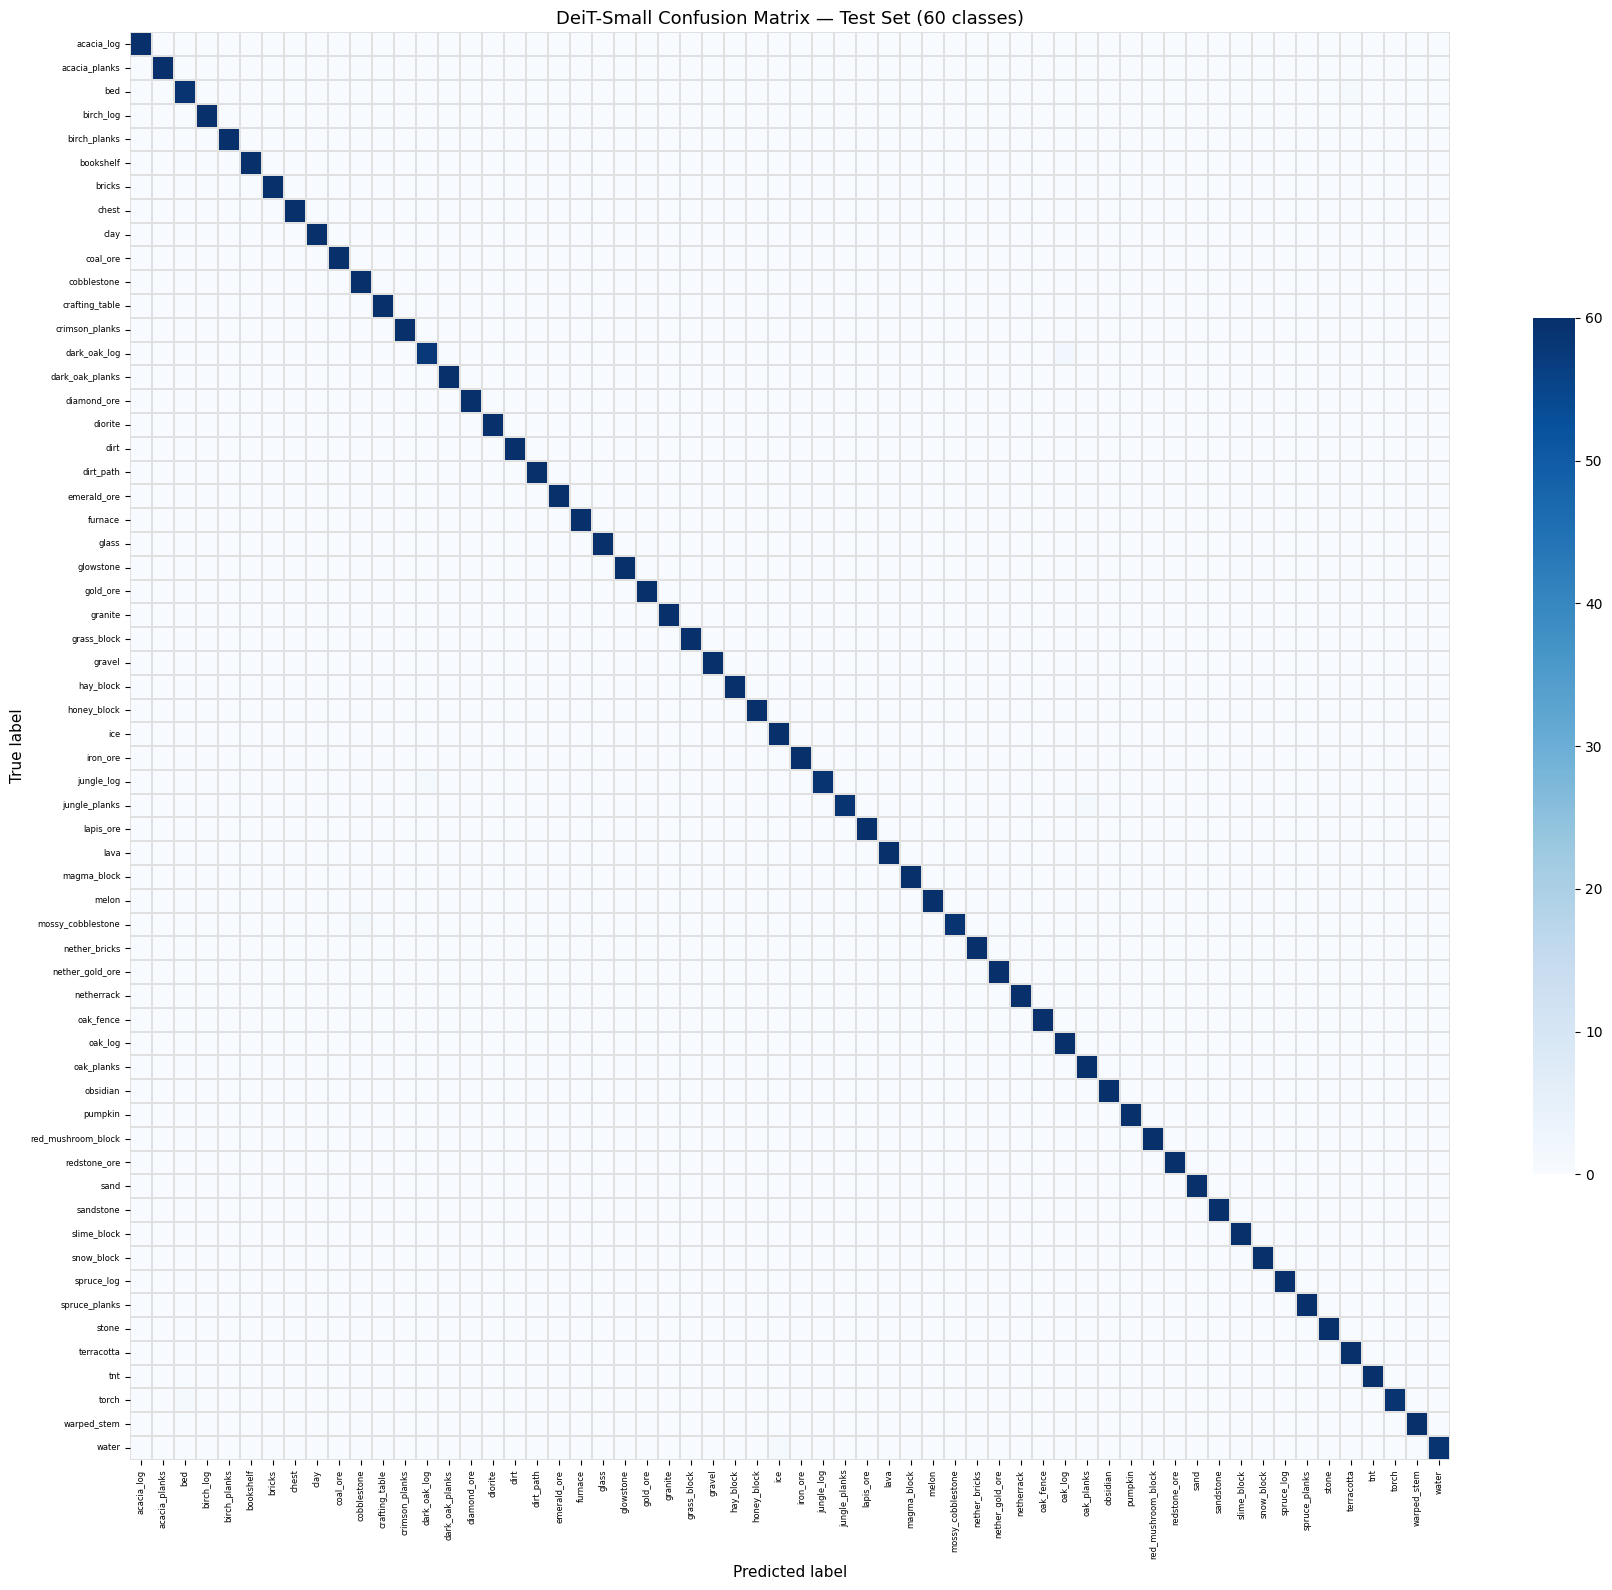

=== DeiT-Small top confused class pairs ===


,true,predicted,count
0,dark_oak_log,oak_log,2
1,bed,terracotta,1
2,jungle_log,dark_oak_log,1
3,jungle_planks,oak_planks,1
4,mossy_cobblestone,cobblestone,1
5,torch,bed,1
6,water,ice,1


In [59]:
# ==== 7H. DeiT confusion matrix and most confused pairs ====

vit_cm = confusion_matrix(vit_y_true, vit_y_pred)

fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(
    vit_cm,
    xticklabels=class_names,
    yticklabels=class_names,
    cmap='Blues',
    ax=ax,
    linewidths=0.3,
    linecolor='#e0e0e0',
    cbar_kws={'shrink': 0.6},
)
ax.set_xlabel('Predicted label', fontsize=11)
ax.set_ylabel('True label', fontsize=11)
ax.set_title('DeiT-Small Confusion Matrix — Test Set (60 classes)', fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=6)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=6)
plt.tight_layout()
os.makedirs(RESULTS_MS4_DIR, exist_ok=True)
plt.savefig(os.path.join(RESULTS_MS4_DIR, 'deit_small_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

vit_cm_df = pd.DataFrame(vit_cm, index=class_names, columns=class_names)
np.fill_diagonal(vit_cm_df.values, 0)

vit_confused = (
    vit_cm_df.stack()
    .reset_index()
    .rename(columns={'level_0': 'true', 'level_1': 'predicted', 0: 'count'})
    .query('count > 0')
    .sort_values('count', ascending=False)
    .head(15)
    .reset_index(drop=True)
)

print('=== DeiT-Small top confused class pairs ===')
display(vit_confused)

In [74]:
print("Linear history keys:")
print(deit_linear_history.keys())

print("\nFine-tuning history keys:")
print(deit_finetune_history.keys())

Linear history keys:
dict_keys(['train_loss', 'train_acc', 'train_f1', 'val_loss', 'val_acc', 'val_f1'])

Fine-tuning history keys:
dict_keys(['train_loss', 'train_acc', 'train_f1', 'val_loss', 'val_acc', 'val_f1'])


In [75]:
deit_summary = pd.DataFrame([
    {
        "model": "DeiT-Small linear probe",
        "trainable_scope": "classifier head only",
        "best_val_macro_f1": best_linear_val_f1,
        "best_val_accuracy": linear_best_val_acc,
        "test_accuracy": linear_test_acc,
        "test_macro_f1": linear_test_f1,
        "test_loss": linear_test_loss,
    },
    {
        "model": "DeiT-Small full fine-tuning",
        "trainable_scope": "all layers",
        "best_val_macro_f1": best_finetune_val_f1,
        "best_val_accuracy": finetune_best_val_acc,
        "test_accuracy": vit_test_acc,
        "test_macro_f1": vit_test_macro_f1,
        "test_loss": vit_test_loss,
    }
])
display(deit_summary)

,model,trainable_scope,best_val_macro_f1,best_val_accuracy,test_accuracy,test_macro_f1,test_loss
0,DeiT-Small linear probe,classifier head only,0.881103,0.883843,0.889167,0.889237,0.424044
1,DeiT-Small full fine-tuning,all layers,0.994306,0.994439,0.997778,0.997778,0.007951


## 8. Interpretability analysis **[to fill in]**

This section will compare where each architecture focuses when making predictions. The main goal is not only to report accuracy, but also to evaluate whether the models rely on the block surface, lighting, background, or other contextual cues.


### Grad-CAM for ResNet-18 **[to fill in]**

Use Grad-CAM on the final convolutional block of the ResNet-18 baseline. The planned output is a heatmap over the input image showing which spatial regions most influenced the predicted class.

Recommended examples to include:
- Correctly classified easy classes
- The hard pair identified in MS3: `dark_oak_planks` vs. `spruce_planks`
- Any examples where the model appears to rely on background or lighting


In [ ]:
# ==== 8A. Grad-CAM for ResNet-18 [TODO] ====
# Add Grad-CAM helper functions and visualization code here later.
# Suggested target layer: model.layer4[-1]

pass


### Attention rollout for ViT-B/16 **[to fill in]**

Use attention rollout to aggregate attention across transformer layers and map patch-level importance back to the image. This will allow qualitative comparison with the ResNet Grad-CAM maps.

Recommended examples to include:
- Same test images used for Grad-CAM
- Correct and incorrect ViT predictions
- Hard-class comparisons involving plank variants


In [ ]:
# ==== 8B. Attention rollout for ViT-B/16 [TODO] ====
# Add attention extraction and rollout visualization code here later.
# The exact implementation will depend on how the ViT model exposes attention weights.

pass


## 9. Final model comparison and reported results **[to fill in]**

After the ViT and interpretability sections are implemented, summarize both models in a single comparison table.

Suggested final table columns:

| Model | Trainable scope | Test accuracy | Macro F1 | Main failure mode | Interpretability takeaway |
|---|---:|---:|---:|---|---|
| ResNet-18 | layer4 + fc | to fill | to fill | to fill | to fill |
| ViT-B/16 | to fill | to fill | to fill | to fill | to fill |

### Questions to answer in the final write-up
- Does ViT improve over ResNet-18, or are both near the performance ceiling?
- Which classes remain difficult, and are the difficult classes visually intuitive?
- Do Grad-CAM and attention rollout suggest that the models focus on the block itself or on background context?
- What does this imply about CNNs vs. transformers in a structured, non-natural image domain?


In [ ]:
# ==== 9A. Final comparison table [TODO] ====
# Once ViT results are available, build a compact summary DataFrame here.

# Example structure:
# final_results = pd.DataFrame([
#     {'model': 'ResNet-18', 'test_accuracy': test_acc, 'macro_f1': report_df.loc['macro avg', 'f1-score']},
#     {'model': 'ViT-B/16', 'test_accuracy': vit_test_acc, 'macro_f1': vit_report_df.loc['macro avg', 'f1-score']},
# ])
# display(final_results)

pass


## 10. Discussion, limitations, and reproducibility checklist **[to fill in]**

### Main conclusions
- To fill in after ViT results and interpretability outputs are available.

### Limitations
- To fill in after final comparison.

### Reproducibility checklist
- [ ] Main notebook is named clearly: `cs1090b_ms4_main_group77.ipynb`
- [ ] Canvas number and member names are listed at the top
- [ ] Major sections use markdown headings
- [ ] Dependencies are documented in `requirements_ms4.txt` or an install cell
- [ ] Data path is documented and uses relative/local paths when possible
- [ ] Notebook can be restarted and run top-to-bottom when data/checkpoints are available
- [ ] Large raw data files are not included in the final zip
- [ ] Checkpoint paths are explicit
- [ ] Final results are generated in the notebook rather than only pasted as screenshots
